# Intel Core Ultra NPU: GNN Benchmarking

Reproducible benchmarking workflow for GNNs on Intel Core Ultra NPU (Meteor Lake) with OpenVINO, including dataset metadata, per-model benchmarks, and publication-ready figures.

In [ ]:
# Stage 0 - Global setup
import os
import sys
import json
import ctypes
import platform
import warnings
import subprocess
import time
import csv
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import Image, display

# Native imports can crash the kernel in some environments. Defer them until needed.
ov = None
onnx = None

SKIP_NATIVE_IMPORTS = os.environ.get("SKIP_NATIVE_IMPORTS", "0") == "1"

def _try_import_openvino():
    global ov
    if ov is not None or SKIP_NATIVE_IMPORTS:
        return ov
    try:
        import openvino as _ov
        ov = _ov
    except Exception as exc:
        warnings.warn(f"OpenVINO import failed: {exc}")
        ov = None
    return ov

def _try_import_onnx():
    global onnx
    if onnx is not None or SKIP_NATIVE_IMPORTS:
        return onnx
    try:
        import onnx as _onnx
        onnx = _onnx
    except Exception as exc:
        warnings.warn(f"ONNX import failed: {exc}")
        onnx = None
    return onnx

try:
    from ogb.nodeproppred import NodePropPredDataset
except Exception:
    NodePropPredDataset = None

try:
    from analysis.plot_config import apply_ieee_style, IEEE_COLORS, save_figure_dual_format, get_model_category, shorten_label
except Exception:
    def apply_ieee_style():
        plt.style.use("default")
        sns.set_theme(style="whitegrid")

    IEEE_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442", "#000000"]

    def save_figure_dual_format(fig, base_path, dpi=300):
        base_path = Path(base_path)
        fig.savefig(str(base_path) + ".png", dpi=dpi, bbox_inches="tight")
        fig.savefig(str(base_path) + ".svg", bbox_inches="tight")
        plt.close(fig)

    def get_model_category(model_name):
        name = str(model_name).lower()
        if "transformer" in name or "gps" in name:
            return "Transformer"
        return "GNN"

    def shorten_label(label, max_len=16):
        text = str(label)
        if len(text) <= max_len:
            return text
        return text[: max_len - 3] + "..."

DEFAULT_MODELS = [
    "GCN", "GAT", "GraphSAGE", "GIN", "EdgeCNN", "APPNP",
    "ChebNet", "SGC", "GCNII", "PNA", "DiffPool", "MinCutPool",
    "GraphTransformer", "GPS"
]
PRECISIONS = ["fp32", "int8"]
DEVICES = ["NPU", "GPU", "CPU"]
DATASETS = ["ogbn-arxiv", "ogbn-proteins", "ogbn-products"]
ITERATIONS = 100
WARMUP = 5
REPEATS = 3

MODELS_DIR = Path("models")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR = Path("data")

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def _infer_models_from_onnx(models_dir: Path):
    names = set()
    for p in models_dir.glob("*.onnx"):
        stem = p.stem
        stem_lower = stem.lower()
        if stem_lower.endswith("_fp32") or stem_lower.endswith("_int8"):
            base = stem.rsplit("_", 1)[0]
        else:
            base = stem
        names.add(base)
    return sorted(names)

MODELS = DEFAULT_MODELS
inferred_models = _infer_models_from_onnx(MODELS_DIR)
if inferred_models:
    MODELS = inferred_models

for model in MODELS:
    (RESULTS_DIR / model).mkdir(parents=True, exist_ok=True)

try:
    IS_ADMIN = bool(ctypes.windll.shell32.IsUserAnAdmin())
except Exception:
    IS_ADMIN = False

SOCWATCH_EXE = os.environ.get("SOCWATCH_EXE", r"C:\\Program Files\\Intel\\SoCWatch\\socwatch.exe")
if not Path(SOCWATCH_EXE).exists():
    sw_path = shutil.which("socwatch.exe")
    if sw_path:
        SOCWATCH_EXE = sw_path
SOCWATCH_DURATION_S = int(os.environ.get("SOCWATCH_DURATION_S", 30))
SOCWATCH_AVAILABLE = Path(SOCWATCH_EXE).exists()

apply_ieee_style()
sns.set_theme(style="whitegrid")

RUN_START_TIME = time.time()

def _ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)
    return path

def _safe_write_json(path: Path, payload):
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
    except Exception:
        pass

def _normalize_latency_df(df: pd.DataFrame, model_name: str):
    df = df.copy()
    if "model" not in df.columns:
        df["model"] = model_name
    if "dataset" not in df.columns and "dataset_name" in df.columns:
        df["dataset"] = df["dataset_name"]
    if "device" not in df.columns and "target_device" in df.columns:
        df["device"] = df["target_device"]
    if "precision" not in df.columns and "precision_mode" in df.columns:
        df["precision"] = df["precision_mode"]
    rename_map = {
        "o_mean_ms": "mean_ms",
        "mean_latency_ms": "mean_ms",
        "latency_ms": "mean_ms",
        "o_std_ms": "std_ms",
        "std_latency_ms": "std_ms",
        "o_p95_ms": "p95_ms",
        "p95_latency_ms": "p95_ms"
    }
    for src, dst in rename_map.items():
        if src in df.columns and dst not in df.columns:
            df[dst] = df[src]
    if "std_ms" not in df.columns:
        df["std_ms"] = np.nan
    if "p95_ms" not in df.columns:
        df["p95_ms"] = np.nan
    return df

def _build_latency_summary(df: pd.DataFrame, model_name: str):
    df = _normalize_latency_df(df, model_name)
    needed = ["model", "dataset", "device", "precision", "mean_ms", "std_ms", "p95_ms"]
    for col in needed:
        if col not in df.columns:
            df[col] = np.nan
    summary = df[needed].copy()
    summary = summary.groupby(["model", "dataset", "device", "precision"], as_index=False).agg(
        mean_ms=("mean_ms", "mean"),
        std_ms=("std_ms", "mean"),
        p95_ms=("p95_ms", "mean")
    )
    return summary

def _compute_precision_gain(summary_df: pd.DataFrame):
    rows = []
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    for (dataset, device), grp in summary_df.groupby(["dataset", "device"]):
        fp32 = grp.loc[grp["precision"] == "fp32", "mean_ms"]
        int8 = grp.loc[grp["precision"] == "int8", "mean_ms"]
        if fp32.empty or int8.empty:
            continue
        fp32_val = float(fp32.mean())
        int8_val = float(int8.mean())
        speedup = fp32_val / int8_val if int8_val else np.nan
        rows.append({
            "dataset": dataset,
            "device": device,
            "fp32_ms": fp32_val,
            "int8_ms": int8_val,
            "speedup": speedup
        })
    return pd.DataFrame(rows)

def scan_models(models_dir: Path):
    model_precisions = {}
    for p in models_dir.glob("*.onnx"):
        stem = p.stem
        base = stem
        precision = None
        if stem.lower().endswith("_fp32"):
            base = stem.rsplit("_", 1)[0]
            precision = "fp32"
        elif stem.lower().endswith("_int8"):
            base = stem.rsplit("_", 1)[0]
            precision = "int8"
        model_precisions.setdefault(base, set())
        if precision:
            model_precisions[base].add(precision)
    rows = []
    for model in sorted(model_precisions):
        precs = model_precisions[model]
        rows.append({
            "model": model,
            "fp32": "yes" if "fp32" in precs else "no",
            "int8": "yes" if "int8" in precs else "no",
            "status": "ready" if {"fp32", "int8"}.issubset(precs) else "missing"
        })
    return pd.DataFrame(rows), model_precisions

def analyze_cpu_fallback(profile_paths):
    try:
        from analysis.ort_profile_utils import load_events, iter_operator_events
    except Exception as exc:
        return {"error": f"ort_profile_utils_unavailable: {exc}"}
    total_us = 0.0
    cpu_us = 0.0
    per_operator = {}
    for path in profile_paths:
        try:
            events = load_events(path)
            for op_name, dur_us, provider, _ in iter_operator_events(events):
                op = str(op_name)
                if op not in per_operator:
                    per_operator[op] = {"cpu_us": 0.0, "total_us": 0.0}
                per_operator[op]["total_us"] += float(dur_us)
                total_us += float(dur_us)
                if "cpu" in str(provider).lower():
                    per_operator[op]["cpu_us"] += float(dur_us)
                    cpu_us += float(dur_us)
        except Exception:
            continue
    for op, vals in per_operator.items():
        total = vals["total_us"] or 1.0
        vals["cpu_ratio"] = vals["cpu_us"] / total
    ratio = cpu_us / total_us if total_us else 0.0
    return {"cpu_fallback_ratio": ratio, "cpu_us": cpu_us, "total_us": total_us, "per_operator": per_operator}

def run_with_socwatch(model_name, device, precision, output_dir: Path):
    if not SOCWATCH_AVAILABLE:
        raise FileNotFoundError("socwatch_not_found")
    sw_out = _ensure_dir(Path(output_dir) / f"socwatch_{device}_{precision}")
    sw_cmd = [
        SOCWATCH_EXE,
        "-f", "sys",
        "-t", str(SOCWATCH_DURATION_S),
        "-o", str(sw_out / "energy"),
        "--no-gui"
    ]
    sw_proc = subprocess.Popen(sw_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(1)
    t0 = time.perf_counter()
    subprocess.run([
        sys.executable, "analysis/scalability_analyzer.py",
        "--model", model_name,
        "--device", device,
        "--precision", precision,
        "--results-dir", str(output_dir),
        "--iterations", str(ITERATIONS),
        "--warmup", str(WARMUP),
        "--repeats", str(REPEATS),
        "--datasets", ",".join(DATASETS),
        "--dataset-root", "data"
    ], check=False)
    elapsed_s = time.perf_counter() - t0
    try:
        sw_proc.terminate()
        sw_proc.wait(timeout=10)
    except Exception:
        pass
    csv_path = sw_out / "energy_summary.csv"
    result = {
        "device": device,
        "precision": precision,
        "duration_s": elapsed_s,
        "package_mW": None,
        "ia_mW": None,
        "gt_mW": None,
        "dram_mW": None,
        "total_mJ": None
    }
    if csv_path.exists():
        with open(csv_path, newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                result["package_mW"] = float(row.get("Package Power (mW)", 0) or 0)
                result["ia_mW"] = float(row.get("IA Power (mW)", 0) or 0)
                result["gt_mW"] = float(row.get("GT Power (mW)", 0) or 0)
                result["dram_mW"] = float(row.get("DRAM Power (mW)", 0) or 0)
                break
        if result["package_mW"] is not None:
            result["total_mJ"] = result["package_mW"] * elapsed_s
    return result

print(f"Platform: {platform.platform()}")
print(f"Python: {sys.version.split()[0]}")
_ov = _try_import_openvino()
if _ov is not None:
    print(f"OpenVINO: {_ov.__version__}")
print(f"Admin: {'Yes' if IS_ADMIN else 'No'}")
print(f"SoCWatch: {'Found' if SOCWATCH_AVAILABLE else 'Not found'}")


Platform: Windows-10-10.0.26200-SP0
Python: 3.11.6
OpenVINO: 2025.4.1-20426-82bbf0292c5-releases/2025/4
Admin: Yes
SoCWatch: Found


In [2]:
# Patch: allow profiling trace discovery in nested run directories
from pathlib import Path as _Path

if not getattr(_Path, "_profile_glob_patched", False):
    _orig_glob = _Path.glob

    def _patched_glob(self, pattern):
        if pattern == "run_*/optimized_profiling.json":
            return _orig_glob(self, "**/run_*/optimized_profiling.json")
        return _orig_glob(self, pattern)

    _Path.glob = _patched_glob
    _Path._profile_glob_patched = True

## Stage 1-A: Dataset metadata loading

In [3]:
# Stage 1A — Dataset metadata (robust loader)
import inspect
import warnings
import torch
import pandas as pd
import json
import tempfile
import textwrap
import importlib.util

# A safe wrapper for torch.load that retries with weights_only=False when supported.
# Only do the retry for trusted files because it may execute arbitrary code.
def safe_torch_load(path, map_location=None, **kwargs):
    sig = inspect.signature(torch.load)
    supports_weights_only = 'weights_only' in sig.parameters
    try:
        return torch.load(path, map_location=map_location, **kwargs)
    except Exception as exc:
        if supports_weights_only:
            warnings.warn(
                f"Primary torch.load failed for {path!r} ({exc}). Retrying with weights_only=False. "
                "Only do this for trusted files because it may execute arbitrary code."
            )
            return torch.load(path, map_location=map_location, weights_only=False, **kwargs)
        raise

def _module_available(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

missing_optional = [name for name in ("ogb", "torch_geometric") if not _module_available(name)]
if missing_optional:
    print(f"Missing optional deps for dataset stats: {missing_optional}")

# Prefer an existing local dataset root so we do not re-download.
# If data/ogbn_* exists, use data/ as root. Otherwise, fall back to data/ogb if present.
expected_dirs = [DATA_DIR / key.replace("-", "_") for key in DATASETS]
if any(d.exists() for d in expected_dirs):
    dataset_root = DATA_DIR
elif (DATA_DIR / "ogb").exists():
    dataset_root = DATA_DIR / "ogb"
else:
    dataset_root = DATA_DIR

print(f"Using dataset root: {dataset_root}")

# Run dataset parsing in a subprocess to avoid kernel crashes from native libs.
use_subprocess = os.environ.get("DATASET_SUBPROCESS", "1") == "1"
dataset_rows = []

if use_subprocess:
    script = textwrap.dedent("""
        import json
        import inspect
        import warnings
        import torch
        from ogb.nodeproppred import PygNodePropPredDataset

        def safe_torch_load(path, map_location=None, **kwargs):
            sig = inspect.signature(torch.load)
            supports_weights_only = 'weights_only' in sig.parameters
            try:
                return torch.load(path, map_location=map_location, **kwargs)
            except Exception as exc:
                if supports_weights_only:
                    warnings.warn(
                        f"Primary torch.load failed for {path!r} ({exc}). Retrying with weights_only=False. "
                        "Only do this for trusted files because it may execute arbitrary code."
                    )
                    return torch.load(path, map_location=map_location, weights_only=False, **kwargs)
                raise

        def main(cfg_path):
            with open(cfg_path, 'r', encoding='utf-8') as f:
                cfg = json.load(f)
            dataset_root = cfg['dataset_root']
            datasets = cfg['datasets']

            rows = []
            orig_torch_load = torch.load
            torch.load = safe_torch_load
            try:
                for dataset_key in datasets:
                    error = None
                    try:
                        ds = PygNodePropPredDataset(name=dataset_key, root=dataset_root)
                        data = ds[0]
                        num_nodes = getattr(data, 'num_nodes', None) or (data.num_nodes if hasattr(data, 'num_nodes') else None)
                        num_edges = getattr(data, 'num_edges', None) or (data.num_edges if hasattr(data, 'num_edges') else None)
                        num_features = getattr(data, 'num_node_features', None) or getattr(data, 'x', None)
                        if hasattr(num_features, 'shape'):
                            num_features = num_features.shape[1] if num_features is not None else None
                        num_classes = getattr(ds, 'num_classes', None)
                    except Exception as exc:
                        warnings.warn(f"Dataset load failed for {dataset_key}: {exc}")
                        num_nodes = num_edges = num_features = num_classes = None
                        error = str(exc)
                    rows.append({
                        'dataset': dataset_key,
                        'num_nodes': num_nodes,
                        'num_edges': num_edges,
                        'num_features': num_features,
                        'num_classes': num_classes,
                        'edges_per_node': (None if (num_nodes is None or num_edges is None) else num_edges / num_nodes),
                        'error': error,
                    })
            finally:
                torch.load = orig_torch_load

            with open(cfg['out_path'], 'w', encoding='utf-8') as f:
                json.dump(rows, f)

        if __name__ == '__main__':
            import sys
            main(sys.argv[1])
    """)

    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False, encoding="utf-8") as script_file:
        script_file.write(script)
        script_path = script_file.name

    with tempfile.NamedTemporaryFile("w", suffix=".json", delete=False, encoding="utf-8") as cfg_file:
        cfg = {
            "dataset_root": str(dataset_root),
            "datasets": DATASETS,
            "out_path": cfg_file.name + ".out.json"
        }
        json.dump(cfg, cfg_file)
        cfg_path = cfg_file.name

    try:
        result = subprocess.run([sys.executable, script_path, cfg_path], check=False, capture_output=True, text=True)
        out_path = cfg["out_path"]
        if Path(out_path).exists():
            with open(out_path, "r", encoding="utf-8") as f:
                dataset_rows = json.load(f)
        else:
            warnings.warn("Dataset subprocess did not produce output; using empty stats.")
            dataset_rows = []
        if result.returncode != 0:
            print(f"Dataset subprocess failed (returncode={result.returncode}).")
            if result.stderr:
                print(result.stderr)
            elif result.stdout:
                print(result.stdout)
    finally:
        try:
            Path(script_path).unlink(missing_ok=True)
            Path(cfg_path).unlink(missing_ok=True)
            Path(cfg["out_path"]).unlink(missing_ok=True)
        except Exception:
            pass
else:
    # Fallback: in-process load (may crash if native libs are unstable)
    try:
        from ogb.nodeproppred import PygNodePropPredDataset
        orig_torch_load = torch.load
        torch.load = safe_torch_load
        try:
            for dataset_key in DATASETS:
                error = None
                try:
                    ds = PygNodePropPredDataset(name=dataset_key, root=str(dataset_root))
                    data = ds[0]
                    num_nodes = getattr(data, 'num_nodes', None) or (data.num_nodes if hasattr(data, 'num_nodes') else None)
                    num_edges = getattr(data, 'num_edges', None) or (data.num_edges if hasattr(data, 'num_edges') else None)
                    num_features = getattr(data, 'num_node_features', None) or getattr(data, 'x', None)
                    if hasattr(num_features, 'shape'):
                        num_features = num_features.shape[1] if num_features is not None else None
                    num_classes = getattr(ds, 'num_classes', None)
                except Exception as exc:
                    warnings.warn(f"Dataset load failed for {dataset_key}: {exc}")
                    num_nodes = num_edges = num_features = num_classes = None
                    error = str(exc)
                dataset_rows.append({
                    'dataset': dataset_key,
                    'num_nodes': num_nodes,
                    'num_edges': num_edges,
                    'num_features': num_features,
                    'num_classes': num_classes,
                    'edges_per_node': (None if (num_nodes is None or num_edges is None) else num_edges / num_nodes),
                    'error': error,
                })
        finally:
            torch.load = orig_torch_load
    except Exception as exc:
        warnings.warn(f"Dataset load failed: {exc}")
        dataset_rows = []

# DataFrame for downstream code and nicer display
dataset_stats = pd.DataFrame(dataset_rows)
print(dataset_stats)
if "error" in dataset_stats.columns and dataset_stats["error"].notna().any():
    print("Dataset load errors:")
    print(dataset_stats[["dataset", "error"]])
    print("Hint: install compatible ogb + torch_geometric and verify dataset cache.")

# Model file discovery (keep existing behaviour but make it explicit)
candidates = sorted([p.name for p in MODELS_DIR.glob('*.onnx')])
# Infer base model names (strip precision suffix)
from collections import defaultdict
model_precisions = defaultdict(lambda: {'fp32': False, 'int8': False})
for name in candidates:
    lname = name.lower()
    if lname.endswith('_fp32.onnx'):
        base = name[:-len('_fp32.onnx')]
        model_precisions[base]['fp32'] = True
    elif lname.endswith('_int8.onnx'):
        base = name[:-len('_int8.onnx')]
        model_precisions[base]['int8'] = True

rows = []
for m in sorted(model_precisions.keys()):
    status = 'ready' if model_precisions[m]['fp32'] and model_precisions[m]['int8'] else 'missing'
    rows.append({'model': m, 'fp32': 'yes' if model_precisions[m]['fp32'] else 'no',
                 'int8': 'yes' if model_precisions[m]['int8'] else 'no', 'status': status})
report_df = pd.DataFrame(rows)
print(report_df)

# Build lists used by later cells
available_models = sorted(list(model_precisions.keys()))
missing_models = [r['model'] for r in rows if r['status'] == 'missing']
print("Missing variants:", missing_models)


Using dataset root: data
         dataset num_nodes num_edges num_features num_classes edges_per_node  \
0     ogbn-arxiv      None      None         None        None           None   
1  ogbn-proteins      None      None         None        None           None   
2  ogbn-products      None      None         None        None           None   

                                               error  
0  maximum recursion depth exceeded while calling...  
1  maximum recursion depth exceeded while calling...  
2  maximum recursion depth exceeded while calling...  
Dataset load errors:
         dataset                                              error
0     ogbn-arxiv  maximum recursion depth exceeded while calling...
1  ogbn-proteins  maximum recursion depth exceeded while calling...
2  ogbn-products  maximum recursion depth exceeded while calling...
Hint: install compatible ogb + torch_geometric and verify dataset cache.
               model fp32 int8   status
0              APPNP  yes  y

## Stage 1-B: Model files loading

In [4]:
if "scan_models" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    # ------------------------------------------------------------------
    # 1. Scan & display model inventory
    # ------------------------------------------------------------------
    report_df, model_precisions = scan_models(MODELS_DIR)

    # Also detect .failed markers
    _failed_markers = {}
    for _fp in sorted(MODELS_DIR.glob("*.failed")):
        _stem = _fp.stem
        if _stem.lower().endswith("_int8"):
            _base = _stem.rsplit("_", 1)[0]
            _failed_markers[_base] = _fp.read_text(encoding="utf-8").strip()[:120]

    if report_df.empty:
        print("❌ No ONNX models found in models/. Run analysis/model_prep.py first.")
    else:
        # Annotate status with .failed info
        def _annotate_status(row):
            if row["status"] == "ready":
                return "✅ ready"
            base = row["model"]
            if base in _failed_markers:
                return f"⚠️ INT8 failed"
            return "⚠️ missing INT8"
        report_df["status"] = report_df.apply(_annotate_status, axis=1)
        display(report_df)

    # Build availability map for downstream cells
    MODEL_AVAIL = {}
    for _m in report_df["model"]:
        MODEL_AVAIL[_m] = {
            "fp32": report_df[report_df["model"] == _m]["fp32"].values[0] == "yes",
            "int8": report_df[report_df["model"] == _m]["int8"].values[0] == "yes",
        }
    AVAILABLE_MODELS = sorted(MODEL_AVAIL.keys())
    print(f"📦 Available models ({len(AVAILABLE_MODELS)}): {AVAILABLE_MODELS}")

    _missing_int8 = [m for m, v in MODEL_AVAIL.items() if not v["int8"]]
    if _missing_int8:
        print(f"⚠️  FP32-only (INT8 .failed): {_missing_int8}")
        for _m in _missing_int8:
            if _m in _failed_markers:
                print(f"   {_m}: {_failed_markers[_m][:100]}")

    # ------------------------------------------------------------------
    # 2. Density sweep (optional — set DENSITY_SWEEP=1 to run)
    # ------------------------------------------------------------------
    _run_density = os.environ.get("DENSITY_SWEEP", "0") == "1"
    density_dir = RESULTS_DIR / "density_sweep"
    if _run_density and not density_dir.exists():
        print("\n🔬 Running density sweep (this may take a while)...")
        try:
            cmd = [
                sys.executable, "analysis/density_sweep.py",
                "--models-dir", str(MODELS_DIR),
                "--results-dir", str(density_dir),
                "--datasets", ",".join(DATASETS),
                "--iterations", str(ITERATIONS),
                "--repeats", str(REPEATS),
                "--profile",
                "--dataset-root", str(DATA_DIR),
                "--auto-models",
                "--gnn-nodes", "4096",
                "--devices", "CPU,GPU,NPU"
            ]
            subprocess.run(cmd, check=False)
        except Exception as exc:
            print(f"Density sweep failed: {exc}")
    elif not _run_density:
        print("💡 Density sweep skipped (set DENSITY_SWEEP=1 to run).")
    elif density_dir.exists():
        print(f"✅ Density sweep already exists at {density_dir}")

,model,fp32,int8,status
0,APPNP,yes,yes,✅ ready
1,GAT,yes,no,⚠️ missing INT8
2,GATv2,yes,no,⚠️ missing INT8
3,GCN,yes,yes,✅ ready
4,GIN,yes,yes,✅ ready
5,GraphSAGE,yes,yes,✅ ready
6,GraphTransformer,yes,yes,✅ ready
7,MPNN,yes,yes,✅ ready
8,SGC,yes,yes,✅ ready
9,bert-tiny,yes,yes,✅ ready


📦 Available models (14): ['APPNP', 'GAT', 'GATv2', 'GCN', 'GIN', 'GraphSAGE', 'GraphTransformer', 'MPNN', 'SGC', 'bert-tiny', 'efficientnet-b0', 'mobilenetv2', 'resnet50', 'vit-tiny']
⚠️  FP32-only (INT8 .failed): ['GAT', 'GATv2']
💡 Density sweep skipped (set DENSITY_SWEEP=1 to run).


## Stage 1-C: Hardware health check

In [5]:
# Stage 1-C: Hardware health check
ov = _try_import_openvino()
if ov is None:
    print("OpenVINO not available (import failed).")
else:
    try:
        core = ov.Core()
        available = set(core.available_devices)
        print(f"OpenVINO devices: {sorted(available)}")

        # Optional: show NPU plugin version info if present
        if "NPU" in available:
            try:
                npu_ver = core.get_versions("NPU")
                print(f"NPU plugin version: {npu_ver}")
            except Exception as exc:
                print(f"NPU version query failed: {exc}")

        # Build a tiny model for a reliable device health check
        try:
            from openvino import opset8 as ops
            param = ops.parameter([1, 1], dtype=np.float32, name="input")
            relu = ops.relu(param)
            result = ops.result(relu, name="output")
            tiny_model = ov.Model([result], [param], "tiny_health_model")
        except Exception as exc:
            print(f"Failed to build tiny model: {exc}")
            tiny_model = None

        # Optional: test with a real model when explicitly requested
        use_model = os.environ.get("HEALTHCHECK_USE_MODEL", "0") == "1"
        model_path = None
        if use_model:
            model_paths = sorted(MODELS_DIR.glob("*.onnx"))
            if model_paths:
                model_path = model_paths[0]

        rows = []
        for device in DEVICES:
            if device not in available:
                rows.append({"device": device, "available": "no", "status": "not_available"})
                continue

            try:
                if model_path is not None:
                    compiled = core.compile_model(str(model_path), device)
                    rows.append({
                        "device": device,
                        "available": "yes",
                        "status": "ok",
                        "details": f"compiled {model_path.name}"
                    })
                else:
                    if tiny_model is None:
                        raise RuntimeError("tiny_model_unavailable")
                    compiled = core.compile_model(tiny_model, device)
                    compiled({"input": np.zeros([1, 1], dtype=np.float32)})
                    rows.append({"device": device, "available": "yes", "status": "ok"})
            except Exception as exc:
                rows.append({
                    "device": device,
                    "available": "yes",
                    "status": f"failed: {exc.__class__.__name__}",
                    "details": str(exc)
                })

        health_df = pd.DataFrame(rows)
        display(health_df)
        active_devices = [row["device"] for row in rows if row["status"] == "ok"]
        if "NPU" not in active_devices:
            warnings.warn("NPU not available in health check")
        print(f"Active devices: {active_devices}")

        # Keep downstream cells aligned with what actually works.
        if active_devices:
            DEVICES = active_devices
    except Exception as exc:
        print(f"Health check failed: {exc}")

OpenVINO devices: ['CPU', 'GPU', 'NPU']
NPU plugin version: {'NPU': <Version: 2025.4.1-20426-82bbf0292c5-releases/2025/4 openvino_intel_npu_plugin>}


,device,available,status
0,NPU,yes,ok
1,GPU,yes,ok
2,CPU,yes,ok


Active devices: ['NPU', 'GPU', 'CPU']


## Stage 2: Batch Benchmark — All models × datasets × devices

Runs every model that has an ONNX file under `models/` across all datasets, devices, and
available precisions.  Models that only export as FP32 (e.g. GAT, GATv2) are benchmarked
in FP32 only; the INT8 column is left blank and flagged in the summary.

### What this cell produces per model

| Artifact | File |
|---|---|
| Latency matrix | `results/{model}/scalability_matrix.csv` |
| Latency summary | `results/{model}/latency_summary.csv` |
| INT8 speedup | `results/{model}/precision_gain.csv` |
| CPU fallback | `results/{model}/cpu_fallback.json` |
| Energy (SoCWatch) | `results/{model}/energy.json` |


In [6]:
# Stage 2 — Unified batch benchmark (loop over available models)
if "Path" not in globals():
    print("❌ Stage 0 not executed. Please run the global setup cell first.")
else:
    # ------------------------------------------------------------------
    # 1. Discover exactly what we have on disk
    # ------------------------------------------------------------------
    _avail = {}   # model_name -> {"fp32": bool, "int8": bool}
    for _p in sorted(MODELS_DIR.glob("*.onnx")):
        _stem = _p.stem
        _low = _stem.lower()
        if _low.endswith("_fp32"):
            _base = _stem.rsplit("_", 1)[0]
            _avail.setdefault(_base, {"fp32": False, "int8": False})["fp32"] = True
        elif _low.endswith("_int8"):
            _base = _stem.rsplit("_", 1)[0]
            _avail.setdefault(_base, {"fp32": False, "int8": False})["int8"] = True
        else:
            _avail.setdefault(_stem, {"fp32": False, "int8": False})["fp32"] = True

    # Detect failed INT8 markers
    for _p in sorted(MODELS_DIR.glob("*.failed")):
        _stem = _p.stem
        _low = _stem.lower()
        if _low.endswith("_int8"):
            _base = _stem.rsplit("_", 1)[0]
            _avail.setdefault(_base, {"fp32": False, "int8": False})

    BENCH_MODELS = sorted(_avail.keys())
    print(f"🔍 Discovered {len(BENCH_MODELS)} models on disk: {BENCH_MODELS}")
    for _m in BENCH_MODELS:
        _precs = []
        if _avail[_m]["fp32"]:
            _precs.append("fp32")
        if _avail[_m]["int8"]:
            _precs.append("int8")
        _flag = " ⚠️ INT8 missing" if not _avail[_m]["int8"] else ""
        print(f"   {_m}: {', '.join(_precs)}{_flag}")

    # ------------------------------------------------------------------
    # 2. Determine active devices (respect health check)
    # ------------------------------------------------------------------
    _active_devs = active_devices if "active_devices" in globals() and active_devices else DEVICES
    print(f"🖥️  Active devices: {_active_devs}")

    # ------------------------------------------------------------------
    # 3. Run benchmark for every model × dataset × device × precision
    # ------------------------------------------------------------------
    ALL_RESULTS = {}   # model_name -> latency_summary DataFrame

    for _mi, MODEL_NAME in enumerate(BENCH_MODELS):
        _prec_list = []
        if _avail[MODEL_NAME]["fp32"]:
            _prec_list.append("fp32")
        if _avail[MODEL_NAME]["int8"]:
            _prec_list.append("int8")
        if not _prec_list:
            print(f"⏭️  {MODEL_NAME}: no usable precision, skipping")
            continue

        _prec_str = ",".join(_prec_list)
        model_result_dir = RESULTS_DIR / MODEL_NAME
        model_result_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n{'='*60}")
        print(f"[{_mi+1}/{len(BENCH_MODELS)}] Benchmarking: {MODEL_NAME}  "
              f"precisions={_prec_str}  devices={','.join(_active_devs)}")
        print(f"{'='*60}")

        # --- 3a. Run scalability_analyzer ---
        try:
            cmd = [
                sys.executable, "analysis/scalability_analyzer.py",
                "--model", MODEL_NAME,
                "--models-dir", "models",
                "--results-dir", str(model_result_dir),
                "--datasets", ",".join(DATASETS),
                "--devices", ",".join(_active_devs),
                "--iterations", str(ITERATIONS),
                "--warmup", str(WARMUP),
                "--repeats", str(REPEATS),
                "--profile",
                "--precision", _prec_str,
                "--dataset-root", "data"
            ]
            print(f"   ▶️  {MODEL_NAME}: scalability_analyzer...")
            subprocess.run(cmd, check=False)
        except Exception as exc:
            print(f"   ❌ Benchmark subprocess failed: {exc}")

        # --- 3b. Load latency summary ---
        latency_summary = None
        try:
            csv_path = model_result_dir / "scalability_matrix.csv"
            if csv_path.exists():
                raw_df = pd.read_csv(csv_path)
                latency_df = _normalize_latency_df(raw_df, MODEL_NAME)
                latency_summary = _build_latency_summary(latency_df, MODEL_NAME)
                latency_summary.to_csv(model_result_dir / "latency_summary.csv", index=False)
                ALL_RESULTS[MODEL_NAME] = latency_summary
            else:
                print(f"   ⚠️  Missing scalability_matrix.csv — skipping latency for {MODEL_NAME}")
        except Exception as exc:
            print(f"   ⚠️  Latency load failed: {exc}")

        # --- 3c. INT8 precision gain ---
        try:
            if latency_summary is not None and not latency_summary.empty:
                precision_gain_df = _compute_precision_gain(latency_summary)
                if not precision_gain_df.empty:
                    precision_gain_df.to_csv(model_result_dir / "precision_gain.csv", index=False)
        except Exception as exc:
            print(f"   ⚠️  Precision gain failed: {exc}")

        # --- 3d. CPU fallback analysis ---
        try:
            traces = sorted(model_result_dir.glob("run_*/optimized_profiling.json"))
            if traces:
                cpu_fallback = analyze_cpu_fallback(traces)
            else:
                cpu_fallback = {"cpu_fallback_ratio": None}
            _safe_write_json(model_result_dir / "cpu_fallback.json", cpu_fallback)
        except Exception as exc:
            print(f"   ⚠️  CPU fallback analysis failed: {exc}")

        # --- 3e. Energy measurement (SoCWatch, admin-only) ---
        energy_results = {}
        try:
            if not IS_ADMIN:
                energy_results = {"error": "admin_required"}
                print("   ⚡ Admin required for SoCWatch — skipping energy")
            elif not SOCWATCH_AVAILABLE:
                energy_results = {"error": "socwatch_not_found"}
                print("   ⚡ SoCWatch not found — skipping energy")
            else:
                for _dev in _active_devs:
                    for _prec in _prec_list:
                        _key = f"{_dev}_{_prec}"
                        try:
                            energy_results[_key] = run_with_socwatch(
                                MODEL_NAME, _dev, _prec, model_result_dir
                            )
                        except FileNotFoundError:
                            energy_results = {"error": "socwatch_not_found"}
                            break
                        except Exception as _exc:
                            energy_results[_key] = {"error": str(_exc)}
            _safe_write_json(model_result_dir / "energy.json", energy_results)
        except Exception as exc:
            print(f"   ⚠️  Energy measurement failed: {exc}")

    # ------------------------------------------------------------------
    # 4. Print unified summary table
    # ------------------------------------------------------------------
    print(f"\n{'='*80}")
    print("📊  UNIFIED BENCHMARK SUMMARY")
    print(f"{'='*80}")

    _summary_rows = []
    for MODEL_NAME in BENCH_MODELS:
        ls = ALL_RESULTS.get(MODEL_NAME)
        if ls is None or ls.empty:
            _summary_rows.append({"model": MODEL_NAME, "status": "no_latency_data"})
            continue

        # Precision gain map
        pg_path = RESULTS_DIR / MODEL_NAME / "precision_gain.csv"
        gain_map = {}
        if pg_path.exists():
            try:
                _pg = pd.read_csv(pg_path)
                gain_map = {(_r["dataset"], _r["device"]): _r["speedup"]
                            for _, _r in _pg.iterrows()}
            except Exception:
                pass

        for _ds in sorted(ls["dataset"].dropna().unique()):
            for _dev in sorted(ls["device"].dropna().unique()):
                _fp32 = ls[(ls["dataset"] == _ds) & (ls["device"] == _dev)
                           & (ls["precision"] == "fp32")]["mean_ms"]
                _int8 = ls[(ls["dataset"] == _ds) & (ls["device"] == _dev)
                           & (ls["precision"] == "int8")]["mean_ms"]
                _fp32_v = float(_fp32.mean()) if not _fp32.empty else float("nan")
                _int8_v = float(_int8.mean()) if not _int8.empty else float("nan")
                _speedup = gain_map.get((_ds, _dev))
                _summary_rows.append({
                    "model": MODEL_NAME, "dataset": _ds, "device": _dev,
                    "fp32_ms": _fp32_v, "int8_ms": _int8_v,
                    "speedup": _speedup if _speedup is not None else float("nan")
                })

    if _summary_rows:
        _sum_df = pd.DataFrame(_summary_rows)
        _sum_path = RESULTS_DIR / "figures" / "unified_summary.csv"
        _sum_path.parent.mkdir(parents=True, exist_ok=True)
        _sum_df.to_csv(_sum_path, index=False)
        print(_sum_df.to_string(index=False, na_rep="n/a",
                                formatters={"fp32_ms": "{:.2f}".format,
                                            "int8_ms": "{:.2f}".format,
                                            "speedup": lambda x: f"{x:.2f}x"
                                            if isinstance(x, (int, float))
                                            and not np.isnan(x) else "n/a"}))
        print(f"\n💾 Full summary saved to: {_sum_path}")
    else:
        print("No benchmark data collected.")

    # ------------------------------------------------------------------
    # 5. Flag INT8 failures for the paper
    # ------------------------------------------------------------------
    _int8_failed = [m for m in BENCH_MODELS if not _avail[m]["int8"] and _avail[m]["fp32"]]
    if _int8_failed:
        print(f"\n⚠️  Models with FP32 only (INT8 quantization failed): {_int8_failed}")
        print("   → Mention in paper: 'Attention-based sparse graph operators (e.g., GAT, GATv2)")
        print("     trigger compilation failures on current OpenVINO NPU toolchains during")
        print("     INT8 quantization due to unsupported dynamic scatter/gather operations.'")


🔍 Discovered 14 models on disk: ['APPNP', 'GAT', 'GATv2', 'GCN', 'GIN', 'GraphSAGE', 'GraphTransformer', 'MPNN', 'SGC', 'bert-tiny', 'efficientnet-b0', 'mobilenetv2', 'resnet50', 'vit-tiny']
   APPNP: fp32, int8
   GAT: fp32 ⚠️ INT8 missing
   GATv2: fp32 ⚠️ INT8 missing
   GCN: fp32, int8
   GIN: fp32, int8
   GraphSAGE: fp32, int8
   GraphTransformer: fp32, int8
   MPNN: fp32, int8
   SGC: fp32, int8
   bert-tiny: fp32, int8
   efficientnet-b0: fp32, int8
   mobilenetv2: fp32, int8
   resnet50: fp32, int8
   vit-tiny: fp32, int8
🖥️  Active devices: ['NPU', 'GPU', 'CPU']

[1/14] Benchmarking: APPNP  precisions=fp32,int8  devices=NPU,GPU,CPU
   ▶️  APPNP: scalability_analyzer...

[2/14] Benchmarking: GAT  precisions=fp32  devices=NPU,GPU,CPU
   ▶️  GAT: scalability_analyzer...

[3/14] Benchmarking: GATv2  precisions=fp32  devices=NPU,GPU,CPU
   ▶️  GATv2: scalability_analyzer...

[4/14] Benchmarking: GCN  precisions=fp32,int8  devices=NPU,GPU,CPU
   ▶️  GCN: scalability_analyzer...

[5

## Stage 3-A: Merge results

In [19]:
# Stage 3-A: Merge per-model results into master dataframe
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)

    # --- Latency merge ---
    paths = sorted(RESULTS_DIR.glob("*/latency_summary.csv"))
    if not paths:
        print("No latency_summary.csv files found — checking unified summary...")
        _uni_path = figures_dir / "unified_summary.csv"
        if _uni_path.exists():
            master_results_df = pd.read_csv(_uni_path)
            print(f"Loaded from unified_summary.csv: {len(master_results_df)} records")
        else:
            master_results_df = pd.DataFrame()
    else:
        dfs = []
        for p in paths:
            try:
                df = pd.read_csv(p)
                dfs.append(df)
            except Exception:
                continue
        master_results_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
        if not master_results_df.empty:
            master_results_df.to_csv(figures_dir / "master_results.csv", index=False)

    print(f"📊 Merged: {len(paths)} model dirs → {len(master_results_df)} records")

    # --- Save dataset_stats for downstream cells ---
    if "dataset_stats" in globals() and dataset_stats is not None and not dataset_stats.empty:
        dataset_stats.to_csv(figures_dir / "dataset_stats.csv", index=False)
        print(f"📋 Dataset stats saved: {len(dataset_stats)} datasets")

📊 Merged: 14 model dirs → 202 records
📋 Dataset stats saved: 3 datasets


## Stage 3-B: Latency and NPU speedup table

In [20]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)
    if "master_results_df" not in globals() or master_results_df.empty:
        print("master_results_df not available.")
    else:
        pivot = master_results_df.pivot_table(
            index="model",
            columns=["device", "precision"],
            values="mean_ms",
            aggfunc="mean"
        )
        pivot.columns = [f"{d}_{p}" for d, p in pivot.columns]
        pivot = pivot.reset_index()
        def _safe_ratio(row, num_col, den_col):
            num = row.get(num_col)
            den = row.get(den_col)
            if num is None or den is None or not np.isfinite(num) or not np.isfinite(den) or den == 0:
                return np.nan
            return num / den
        pivot["npu_vs_cpu_speedup"] = pivot.apply(lambda r: _safe_ratio(r, "CPU_fp32", "NPU_fp32"), axis=1)
        pivot["npu_vs_gpu_speedup"] = pivot.apply(lambda r: _safe_ratio(r, "GPU_fp32", "NPU_fp32"), axis=1)
        pivot = pivot.sort_values("npu_vs_cpu_speedup", ascending=False)
        pivot.to_csv(figures_dir / "comparison_table.csv", index=False)
        print(pivot.to_string(index=False))

                model   CPU_fp32   CPU_int8   GPU_fp32   GPU_int8  NPU_fp32   NPU_int8  npu_vs_cpu_speedup  npu_vs_gpu_speedup
        vit-tiny_fp32 121.035300        NaN   6.418033        NaN  9.150633        NaN           13.226986            0.701376
        resnet50_fp32  33.324133        NaN  11.013567        NaN  3.918933        NaN            8.503368            2.810348
     mobilenetv2_fp32  10.013233        NaN   2.252967        NaN  1.974500        NaN            5.071275            1.141031
 efficientnet-b0_fp32  15.770033        NaN   3.213900        NaN  4.054133        NaN            3.889865            0.792746
             GIN_fp32  46.541600        NaN  40.871000        NaN 42.291633        NaN            1.100492            0.966409
       bert-tiny_fp32   6.683000        NaN        NaN        NaN  6.381333        NaN            1.047273                 NaN
             GAT_fp32  11.093300        NaN   8.511300        NaN 10.603700        NaN            1.046173     

## Stage 3-C: Summary statistics

In [21]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    gain_paths = sorted(RESULTS_DIR.glob("*/precision_gain.csv"))
    for path in gain_paths:
        try:
            model = path.parent.name
            df = pd.read_csv(path)
            if "speedup" not in df.columns or df.empty:
                continue
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "mean", "value": float(df["speedup"].mean())})
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "median", "value": float(df["speedup"].median())})
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "min", "value": float(df["speedup"].min())})
            summary_rows.append({"section": "int8_speedup", "model": model, "metric": "max", "value": float(df["speedup"].max())})
        except Exception:
            continue

    cpu_paths = sorted(RESULTS_DIR.glob("*/cpu_fallback.json"))
    for path in cpu_paths:
        try:
            model = path.parent.name
            payload = json.loads(path.read_text(encoding="utf-8"))
            ratio = payload.get("cpu_fallback_ratio")
            if ratio is None:
                continue
            summary_rows.append({"section": "cpu_fallback", "model": model, "metric": "ratio", "value": float(ratio)})
        except Exception:
            continue

    energy_paths = sorted(RESULTS_DIR.glob("*/energy.json"))
    for path in energy_paths:
        try:
            model = path.parent.name
            payload = json.loads(path.read_text(encoding="utf-8"))
            if payload.get("error"):
                summary_rows.append({"section": "energy", "model": model, "metric": "error", "value": payload.get("error")})
                continue
            for device in DEVICES:
                key = f"{device}_fp32"
                entry = payload.get(key)
                if isinstance(entry, dict):
                    summary_rows.append({"section": "energy", "model": model, "metric": f"{device}_fp32_mJ", "value": entry.get("total_mJ")})
        except Exception:
            continue

    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)

    if "dataset_stats" not in globals() or dataset_stats is None or dataset_stats.empty:
        dataset_stats_path = figures_dir / "dataset_stats.csv"
        if dataset_stats_path.exists():
            dataset_stats = pd.read_csv(dataset_stats_path)

    if "master_results_df" in globals() and not master_results_df.empty and "dataset_stats" in globals() and not dataset_stats.empty:
        npu_df = master_results_df[(master_results_df["device"] == "NPU") & (master_results_df["precision"] == "fp32")]
        npu_mean = npu_df.groupby("dataset", as_index=False)["mean_ms"].mean()
        merged = dataset_stats.merge(npu_mean, on="dataset", how="inner")
        if not merged.empty and merged["edges_per_node"].notna().any():
            try:
                r, p = stats.pearsonr(merged["edges_per_node"], merged["mean_ms"])
                summary_rows.append({"section": "density_latency_correlation", "model": "all", "metric": "pearson_r", "value": float(r)})
                summary_rows.append({"section": "density_latency_correlation", "model": "all", "metric": "p_value", "value": float(p)})
            except Exception:
                pass

    density_dir = RESULTS_DIR / "density_sweep"
    density_rows = []
    if density_dir.exists():
        def _read_metadata(model_dir: Path):
            candidate = model_dir / "run_00" / "input_metadata.json"
            paths = [candidate] if candidate.exists() else sorted(model_dir.glob("run_*/input_metadata.json"))
            for p in paths:
                try:
                    payload = json.loads(p.read_text(encoding="utf-8"))
                    return {k: float(payload.get(k)) for k in ("used_num_nodes", "used_num_edges", "used_num_features") if isinstance(payload.get(k), (int, float))}
                except Exception:
                    continue
            return {}
        for ds_dir in sorted(density_dir.glob("dataset_*")):
            matrix = ds_dir / "scalability_matrix.csv"
            if not matrix.exists():
                continue
            try:
                df_ds = pd.read_csv(matrix)
            except Exception:
                continue
            df_ds["dataset"] = ds_dir.name.replace("dataset_", "")
            if "model" in df_ds.columns:
                meta_list = [_read_metadata(ds_dir / model) for model in df_ds["model"].astype(str)]
                df_ds = pd.concat([df_ds, pd.DataFrame(meta_list)], axis=1)
            if {"used_num_nodes", "used_num_edges"}.issubset(df_ds.columns):
                df_ds["edges_per_node"] = df_ds["used_num_edges"] / df_ds["used_num_nodes"].replace(0, np.nan)
            density_rows.append(df_ds)
    if density_rows:
        density_df = pd.concat(density_rows, ignore_index=True)
        density_df.to_csv(figures_dir / "density_sweep_merged.csv", index=False)
    else:
        print("No density sweep data found.")

    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df.to_csv(figures_dir / "summary_stats.csv", index=False)
    print("Summary stats: ")
    if summary_df.empty:
        print("No summary statistics available.")
    else:
        print(summary_df.head(20).to_string(index=False))

No density sweep data found.
Summary stats: 
     section           model metric    value
int8_speedup           APPNP   mean 0.972170
int8_speedup           APPNP median 0.925441
int8_speedup           APPNP    min 0.888344
int8_speedup           APPNP    max 1.092492
int8_speedup       bert-tiny   mean 0.690180
int8_speedup       bert-tiny median 0.691101
int8_speedup       bert-tiny    min 0.629648
int8_speedup       bert-tiny    max 0.749620
int8_speedup efficientnet-b0   mean 0.816517
int8_speedup efficientnet-b0 median 0.966826
int8_speedup efficientnet-b0    min 0.314703
int8_speedup efficientnet-b0    max 1.200975
int8_speedup             GCN   mean 0.989941
int8_speedup             GCN median 0.974607
int8_speedup             GCN    min 0.960714
int8_speedup             GCN    max 1.034502
int8_speedup             GIN   mean 1.001853
int8_speedup             GIN median 1.026331
int8_speedup             GIN    min 0.830336
int8_speedup             GIN    max 1.050457


## Stage 4-1: Figure 1 - Latency comparison (FP32)

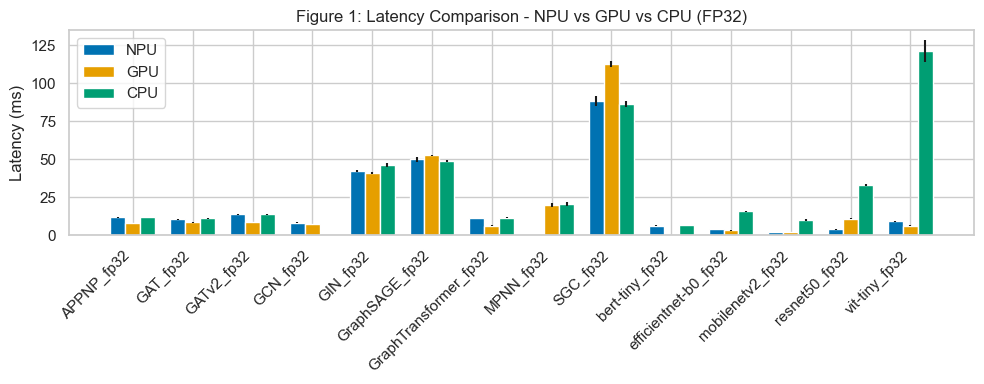

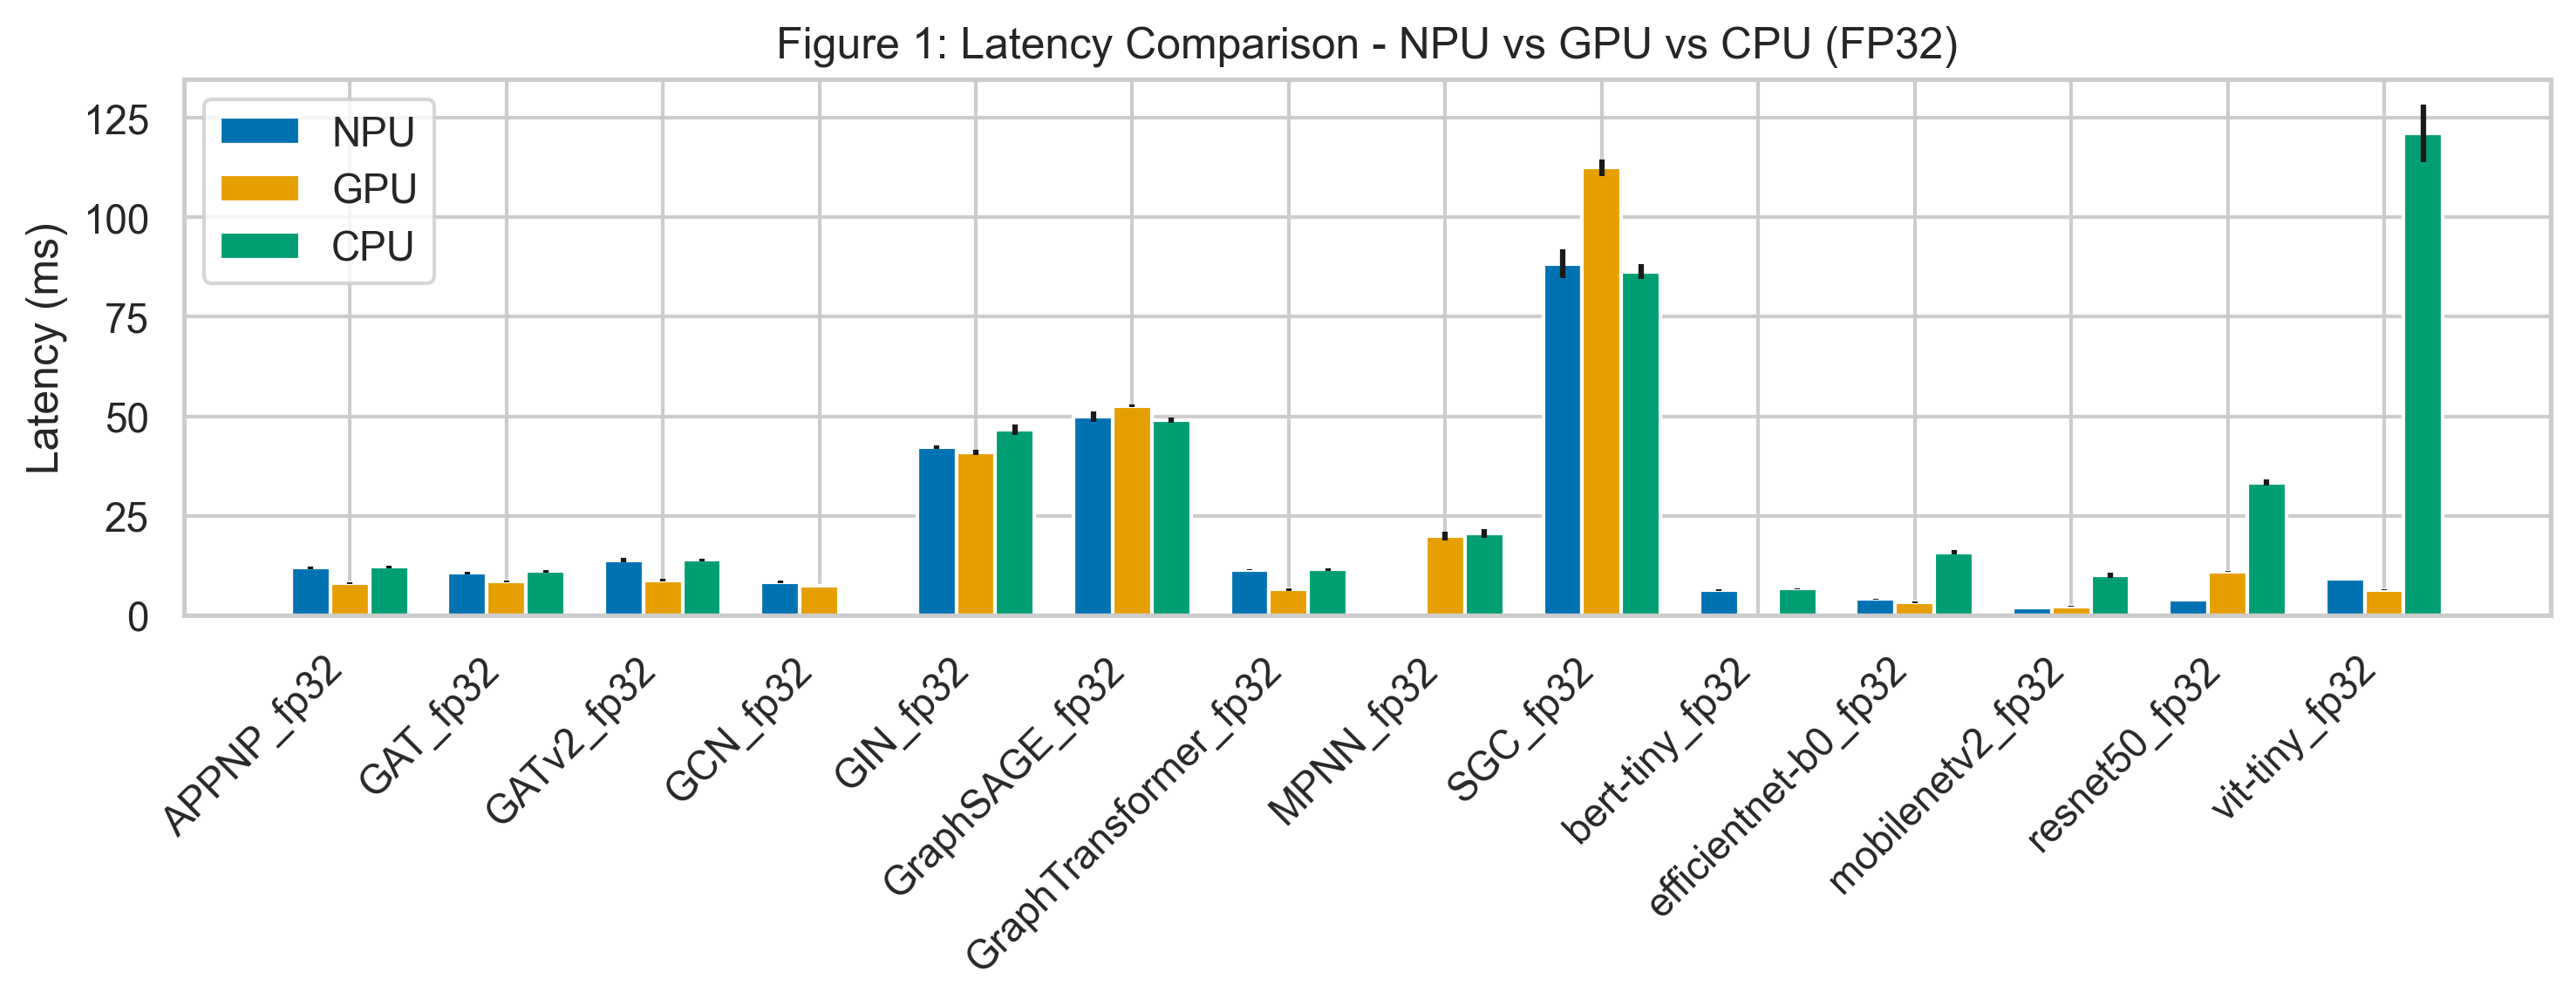

In [22]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)
    if "master_results_df" not in globals() or master_results_df.empty:
        print("Data not found: master_results_df")
    else:
        df = master_results_df[master_results_df["precision"] == "fp32"]
        if df.empty:
            print("No FP32 data available.")
        else:
            mean_df = df.groupby(["model", "device"], as_index=False)["mean_ms"].mean()
            std_df = df.groupby(["model", "device"], as_index=False)["std_ms"].mean()
            mean_pivot = mean_df.pivot(index="model", columns="device", values="mean_ms").fillna(0)
            std_pivot = std_df.pivot(index="model", columns="device", values="std_ms").fillna(0)
            models = list(mean_pivot.index)
            x = np.arange(len(models))
            width = 0.25
            fig, ax = plt.subplots(figsize=(10, 4))
            for i, device in enumerate(["NPU", "GPU", "CPU"]):
                vals = mean_pivot[device] if device in mean_pivot.columns else np.zeros(len(models))
                errs = std_pivot[device] if device in std_pivot.columns else np.zeros(len(models))
                ax.bar(x + (i - 1) * width, vals, width, yerr=errs, label=device, color=IEEE_COLORS[i % len(IEEE_COLORS)])
            ax.set_title("Figure 1: Latency Comparison - NPU vs GPU vs CPU (FP32)")
            ax.set_ylabel("Latency (ms)")
            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=45, ha="right")
            ax.legend()
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig1_latency_comparison")
            display(Image(filename=figures_dir / "fig1_latency_comparison.png"))
    plt.close('all')

## Stage 4-2: Figure 2 - INT8 speedup heatmap

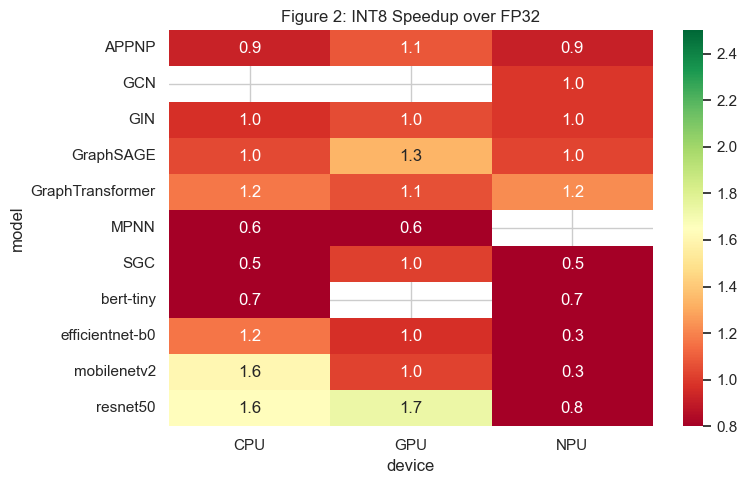

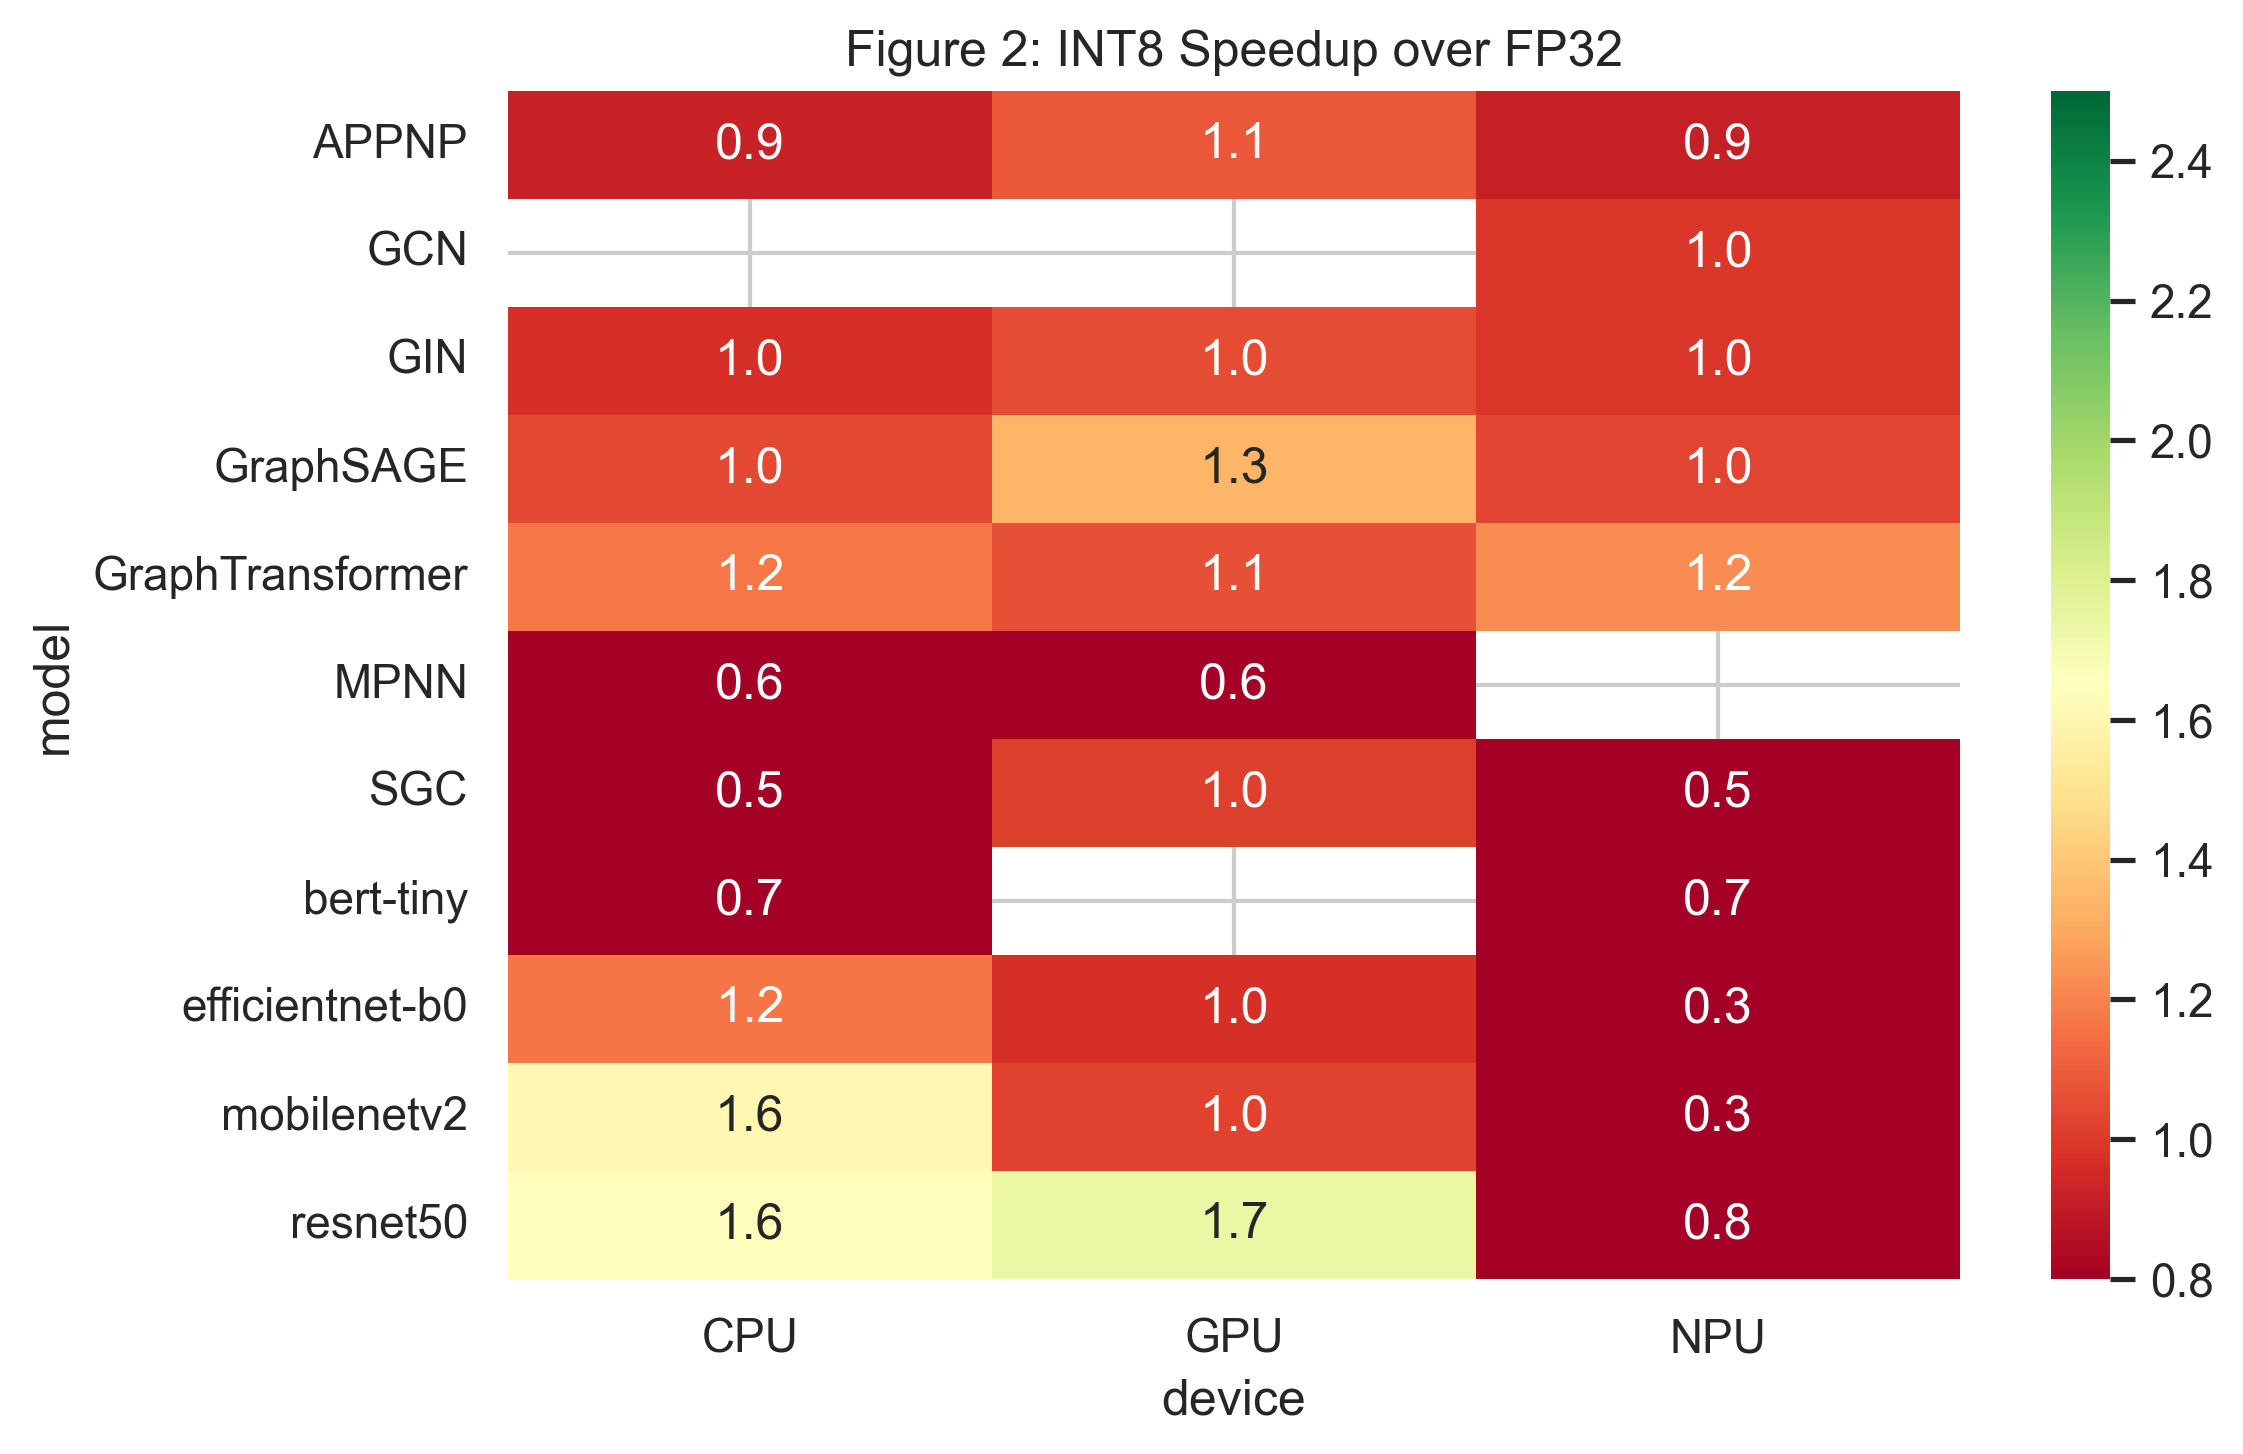

In [23]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    rows = []
    for path in sorted(RESULTS_DIR.glob("*/precision_gain.csv")):
        try:
            model = path.parent.name
            df = pd.read_csv(path)
            if df.empty:
                continue
            for device, grp in df.groupby("device"):
                rows.append({"model": model, "device": device, "speedup": float(grp["speedup"].mean())})
        except Exception:
            continue
    if not rows:
        print("Data not found: precision_gain.csv")
    else:
        heat_df = pd.DataFrame(rows)
        pivot = heat_df.pivot(index="model", columns="device", values="speedup")
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(pivot, ax=ax, cmap="RdYlGn", vmin=0.8, vmax=2.5, annot=True, fmt=".1f")
        ax.set_title("Figure 2: INT8 Speedup over FP32")
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig2_int8_speedup_heatmap")
        display(Image(filename=figures_dir / "fig2_int8_speedup_heatmap.png"))
    plt.close('all')

## Stage 4-3: Figure 3 - Operator breakdown

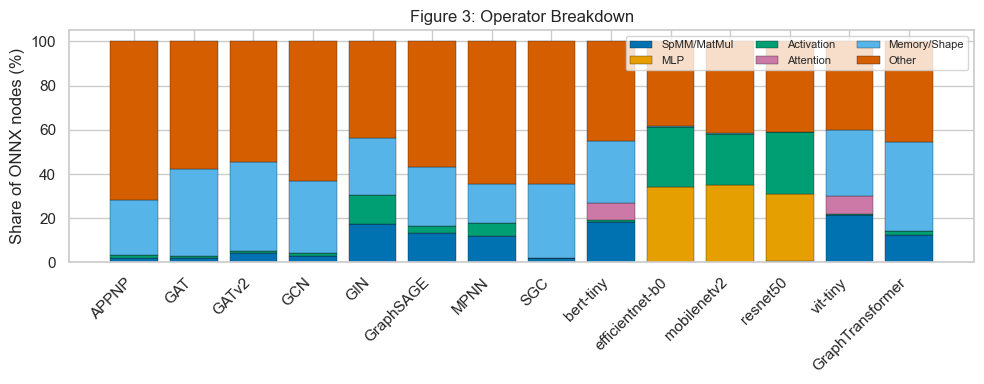

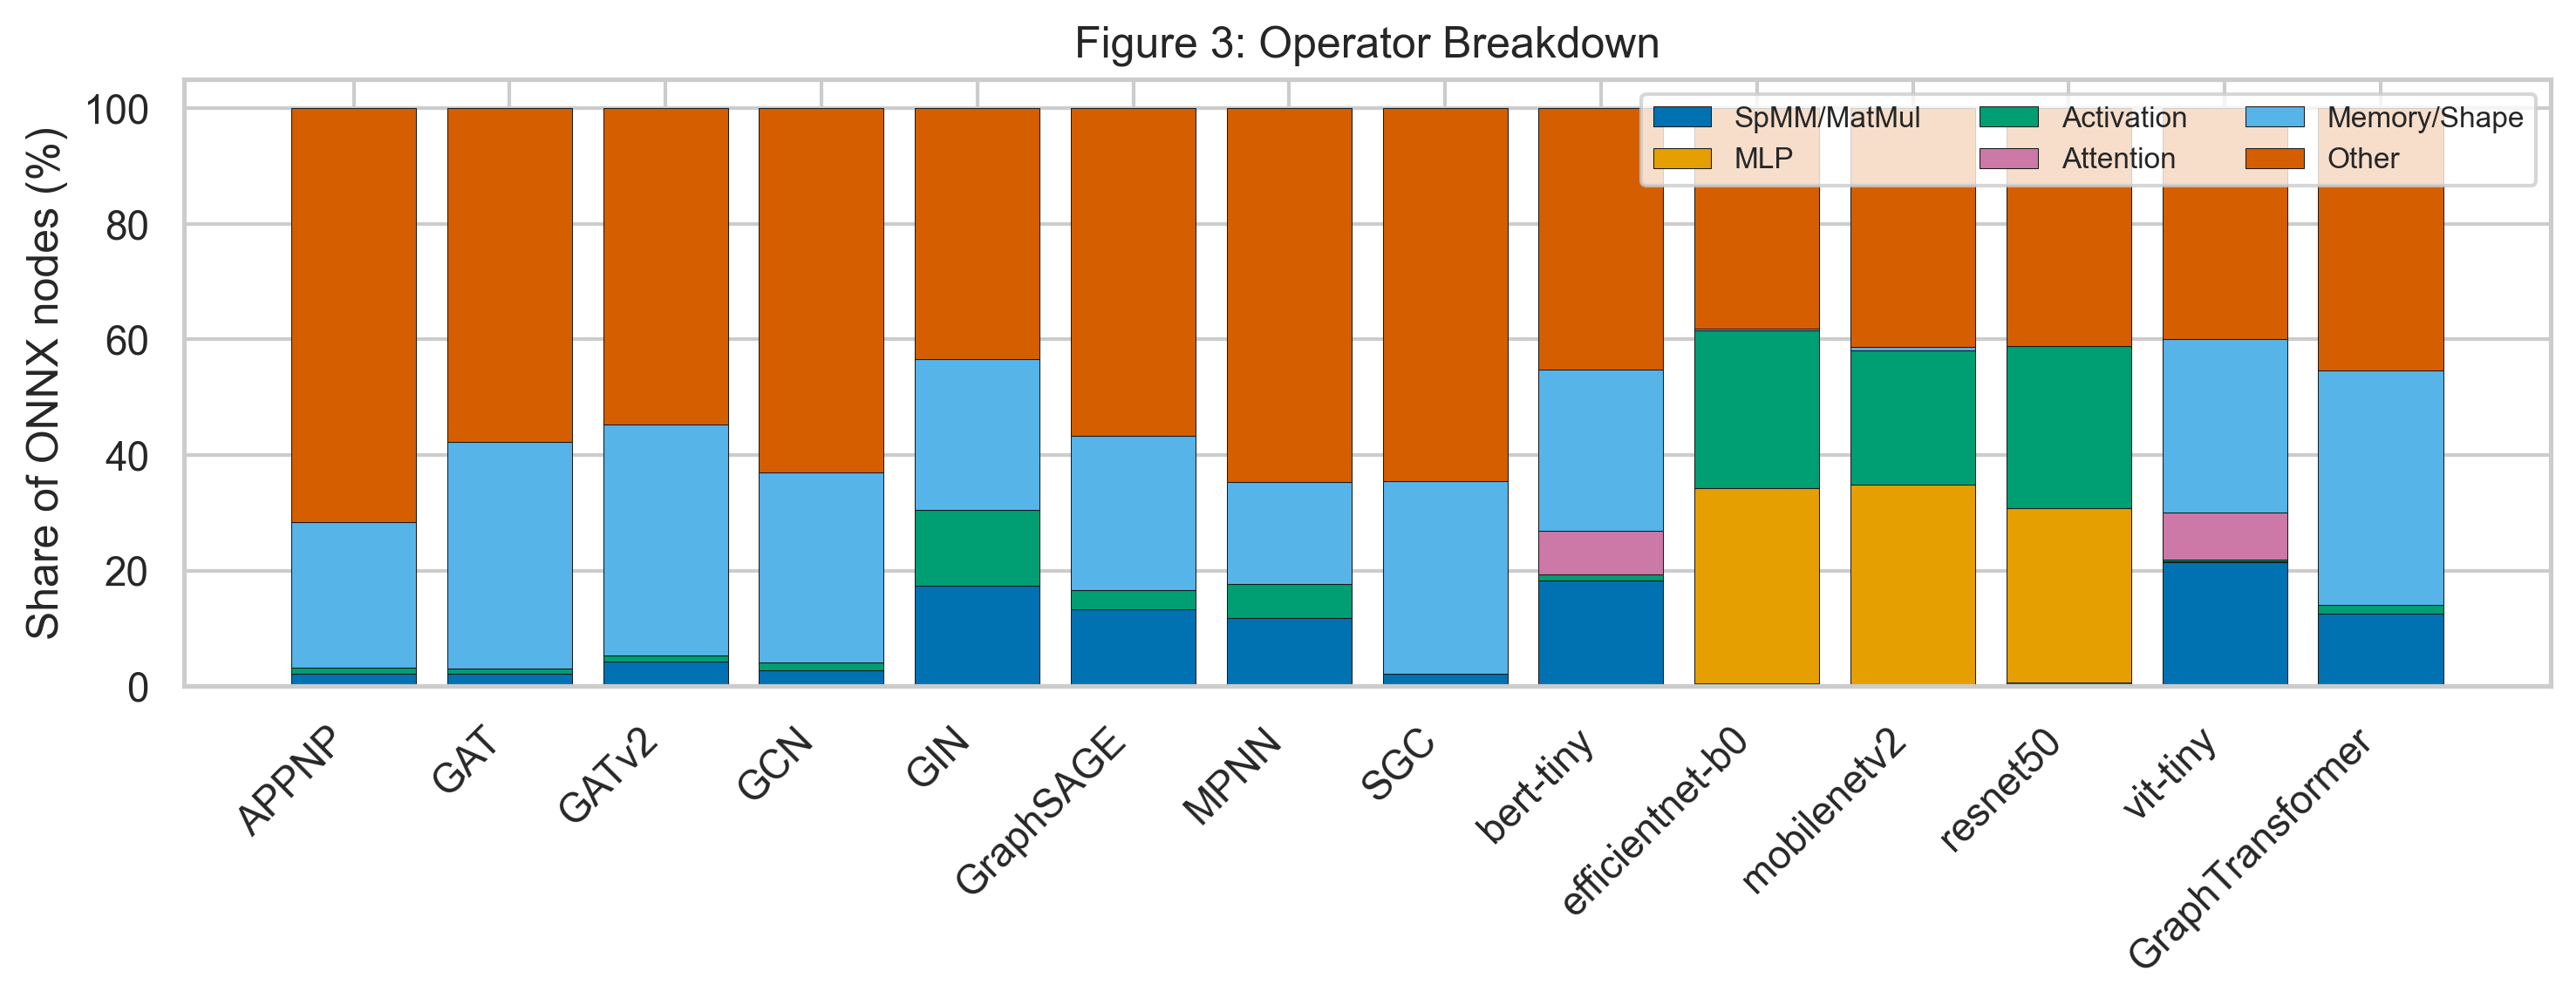

In [24]:
# Stage 4-3: Figure 3 - Operator breakdown (needs onnx import)
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    operator_mix_path = figures_dir / "operator_mix.csv"

    # Ensure ONNX is imported before using it
    _onnx_imported = _try_import_onnx()
    if _onnx_imported is None:
        print("❌ ONNX import failed — cannot analyze operator breakdown. Skipping Figure 3.")
    elif operator_mix_path.exists():
        op_df = pd.read_csv(operator_mix_path)
    else:
        categories = ["SpMM/MatMul", "MLP", "Activation", "Attention", "Memory/Shape", "Other"]
        def _categorize(op_type):
            op = str(op_type)
            if op in {"MatMul", "Gemm"}:
                return "SpMM/MatMul"
            if op in {"Conv", "ConvTranspose", "DepthwiseConv"}:
                return "MLP"
            if "Attention" in op or op in {"Softmax", "LayerNormalization"}:
                return "Attention"
            if op in {"Relu", "Sigmoid", "Tanh", "Gelu"}:
                return "Activation"
            if op in {"Gather", "Scatter", "Slice", "Concat", "Transpose", "Reshape"}:
                return "Memory/Shape"
            return "Other"
        rows = []
        for model_path in sorted(MODELS_DIR.glob("*.onnx")):
            if "fp32" not in model_path.stem.lower():
                continue
            try:
                model = onnx.load(str(model_path))
                counts = {c: 0 for c in categories}
                for node in model.graph.node:
                    counts[_categorize(node.op_type)] += 1
                total = sum(counts.values()) or 1
                row = {k: (v / total) * 100 for k, v in counts.items()}
                row["model"] = model_path.stem.rsplit("_", 1)[0]
                row["category"] = get_model_category(row["model"])
                rows.append(row)
            except Exception:
                continue
        op_df = pd.DataFrame(rows)
        if not op_df.empty:
            op_df.to_csv(operator_mix_path, index=False)

    if "op_df" not in dir() or op_df is None or op_df.empty:
        print("Data not found: operator_mix.csv")
    else:
        categories = ["SpMM/MatMul", "MLP", "Activation", "Attention", "Memory/Shape", "Other"]
        fig, ax = plt.subplots(figsize=(10, 4))
        op_df = op_df.sort_values(["category", "model"])
        x = np.arange(len(op_df))
        bottom = np.zeros(len(op_df))
        for i, cat in enumerate(categories):
            vals = op_df[cat].fillna(0).values
            ax.bar(x, vals, bottom=bottom, label=cat, color=IEEE_COLORS[i % len(IEEE_COLORS)],
                   edgecolor="k", linewidth=0.25)
            bottom += vals
        ax.set_xticks(x)
        ax.set_xticklabels(op_df["model"], rotation=45, ha="right")
        ax.set_ylabel("Share of ONNX nodes (%)")
        ax.set_title("Figure 3: Operator Breakdown")
        ax.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig3_operator_breakdown")
        display(Image(filename=figures_dir / "fig3_operator_breakdown.png"))
    plt.close('all')

## Stage 4-4: Figure 4 - CPU fallback heatmap

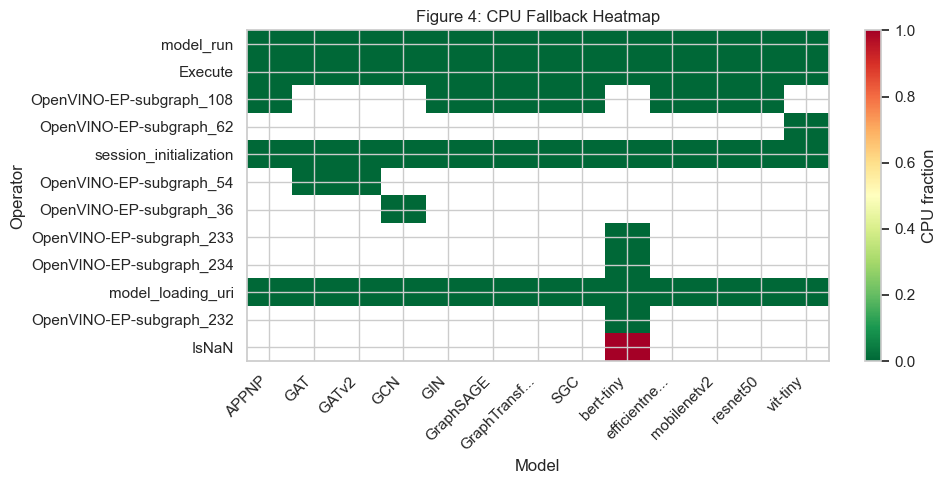

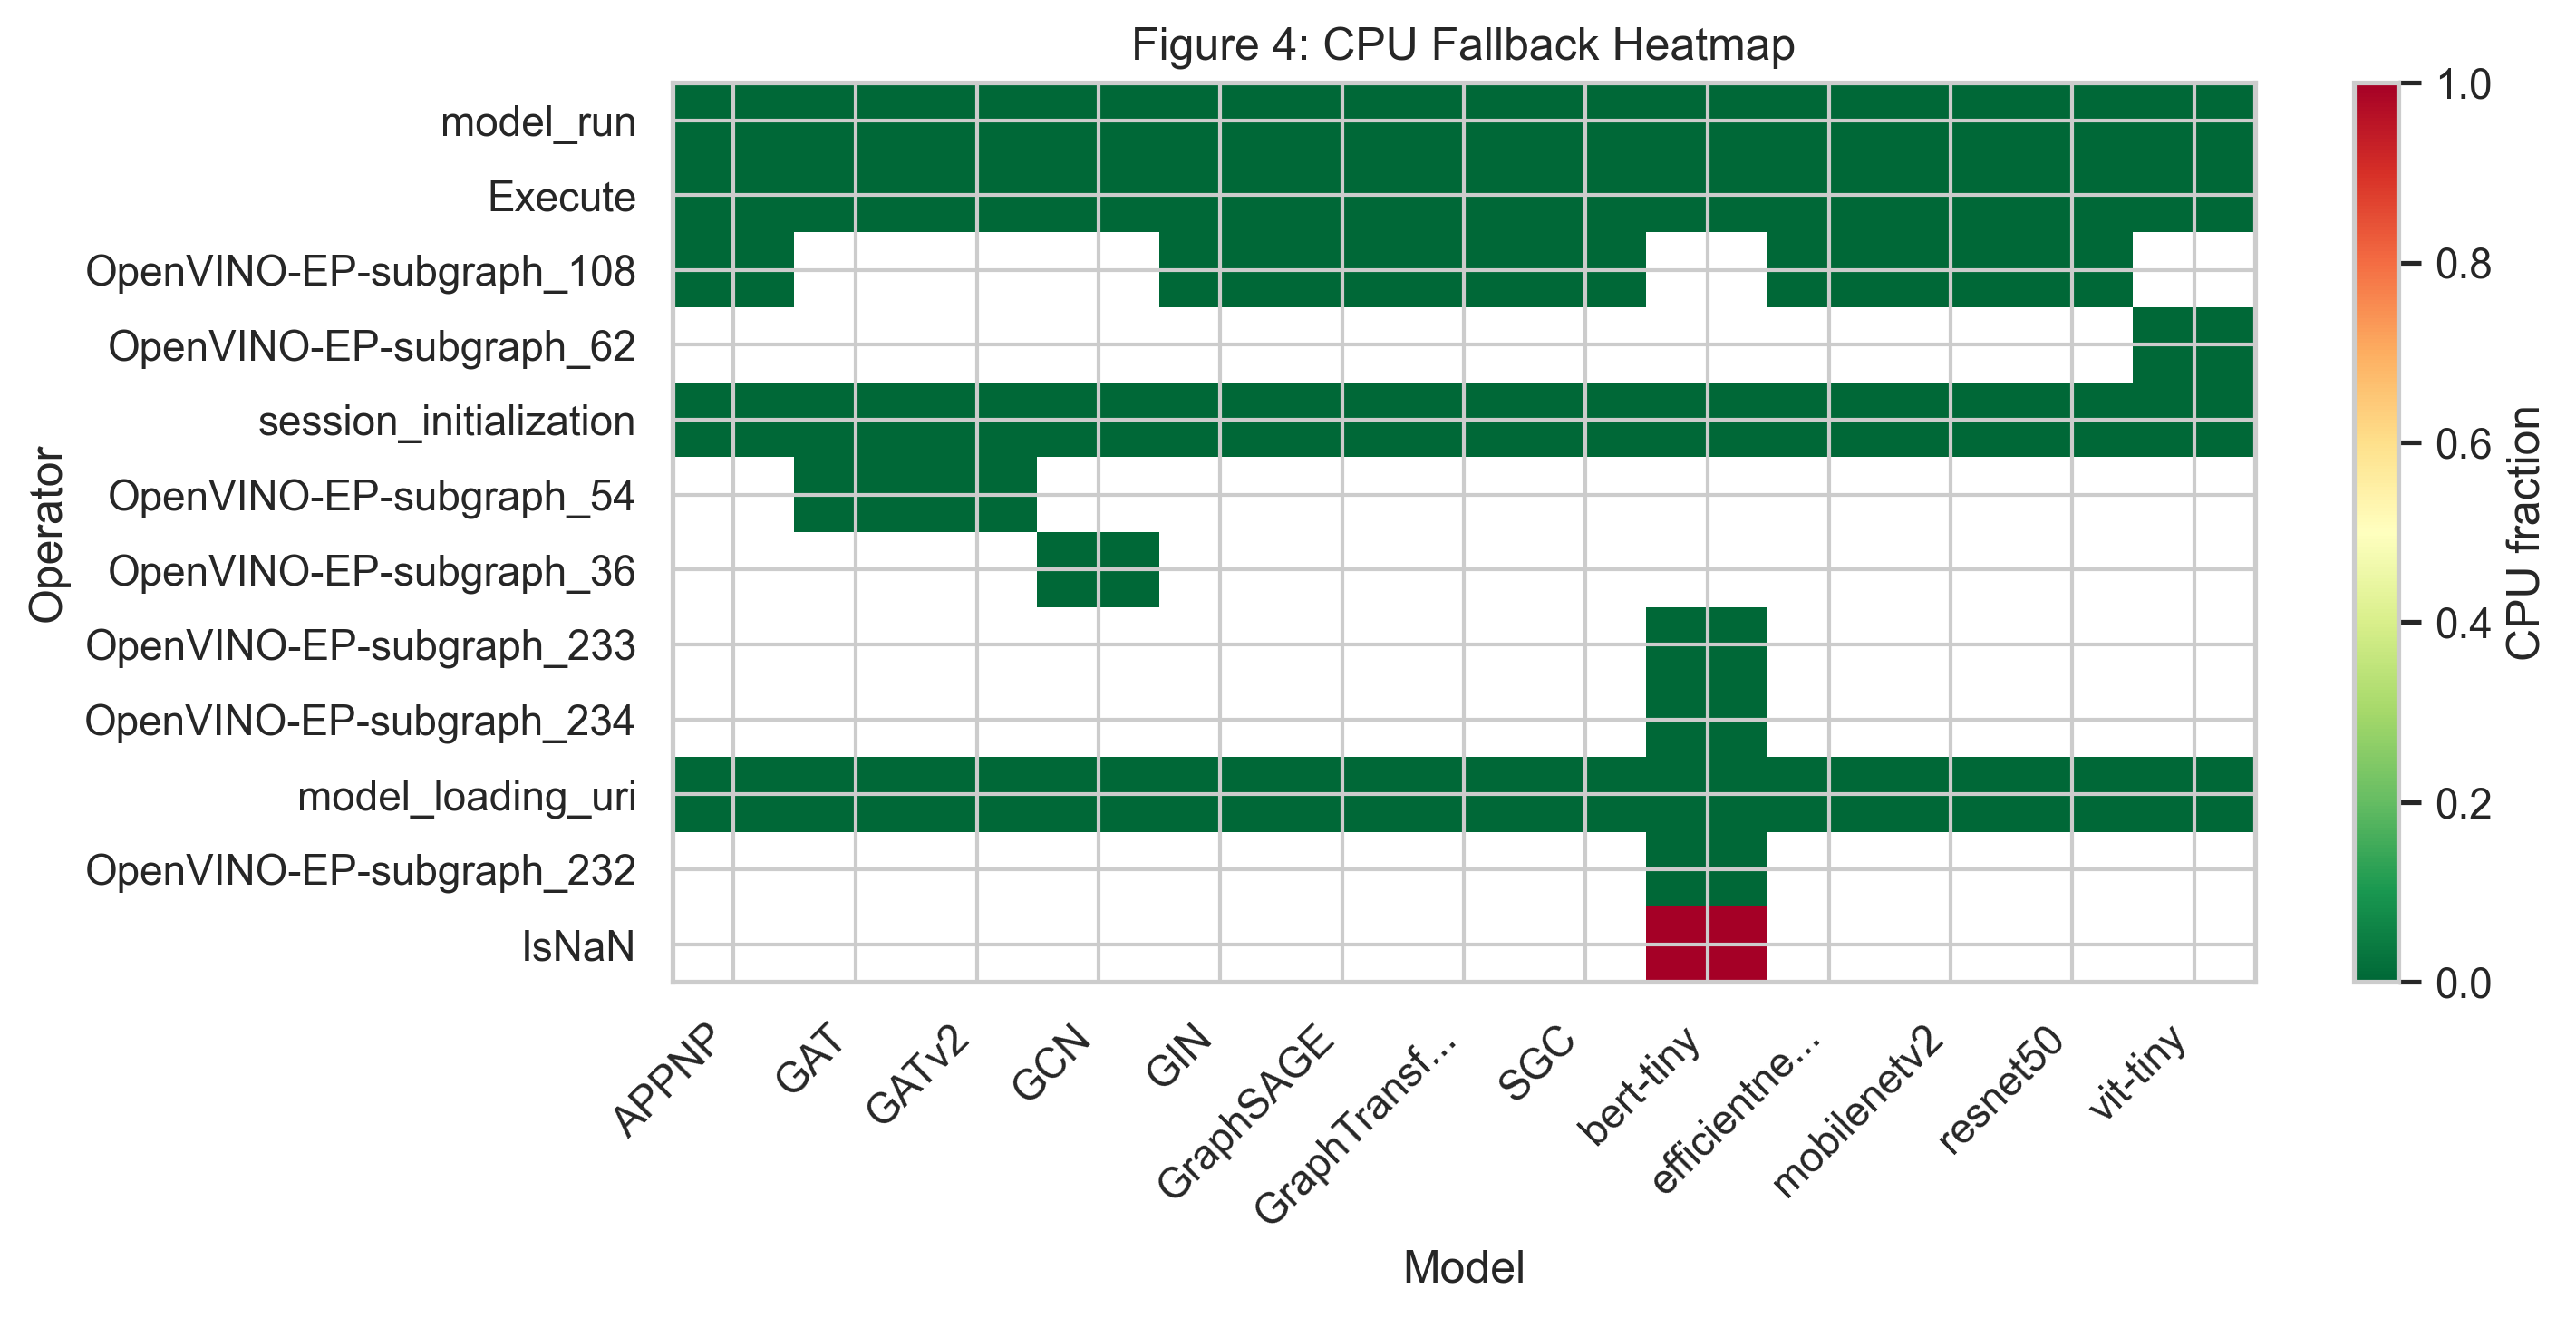

In [25]:
try:
    from analysis.ort_profile_utils import iter_operator_events, load_events
except Exception as exc:
    iter_operator_events = None
    load_events = None
    print(f"ort_profile_utils unavailable: {exc}")

if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
elif load_events is None or iter_operator_events is None:
    print("Data not found: ort_profile_utils")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    model_maps = {}
    op_total_time = {}
    for model_dir in [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name not in {"figures", "density_sweep", "scaling_sweep"}]:
        traces = sorted(model_dir.glob("run_*/optimized_profiling.json"))
        if not traces:
            continue
        try:
            events = load_events(traces[-1])
            sums = {}
            for op_name, dur_us, provider, _ in iter_operator_events(events):
                op = str(op_name)
                if op not in sums:
                    sums[op] = {"cpu": 0.0, "total": 0.0}
                sums[op]["total"] += dur_us
                if "cpu" in str(provider).lower():
                    sums[op]["cpu"] += dur_us
                op_total_time[op] = op_total_time.get(op, 0.0) + dur_us
            cpu_frac = {op: v["cpu"] / v["total"] if v["total"] > 0 else 0 for op, v in sums.items()}
            model_maps[model_dir.name] = cpu_frac
        except Exception:
            continue
    if not model_maps:
        print("No profiling data found.")
    else:
        top_ops = [op for op, _ in sorted(op_total_time.items(), key=lambda x: x[1], reverse=True)[:25]]
        sorted_models = sorted(model_maps.keys())
        mat = np.full((len(top_ops), len(sorted_models)), np.nan)
        for j, model in enumerate(sorted_models):
            mp = model_maps[model]
            for i, op in enumerate(top_ops):
                if op in mp:
                    mat[i, j] = mp[op]
        fig, ax = plt.subplots(figsize=(10, 5))
        im = ax.imshow(mat, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn_r")
        ax.set_xticks(range(len(sorted_models)))
        ax.set_xticklabels([shorten_label(m, 14) for m in sorted_models], rotation=45, ha="right")
        ax.set_yticks(range(len(top_ops)))
        ax.set_yticklabels([shorten_label(op, 30) for op in top_ops])
        ax.set_xlabel("Model")
        ax.set_ylabel("Operator")
        ax.set_title("Figure 4: CPU Fallback Heatmap")
        fig.colorbar(im, ax=ax, label="CPU fraction")
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig4_cpu_fallback_heatmap")
        display(Image(filename=figures_dir / "fig4_cpu_fallback_heatmap.png"))
    plt.close('all')

## Stage 4-5: Figure 5 - Fusion gain vs performance

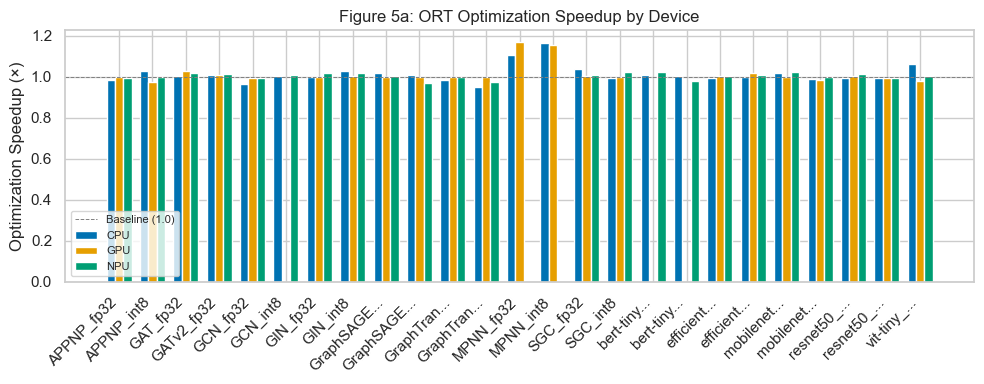

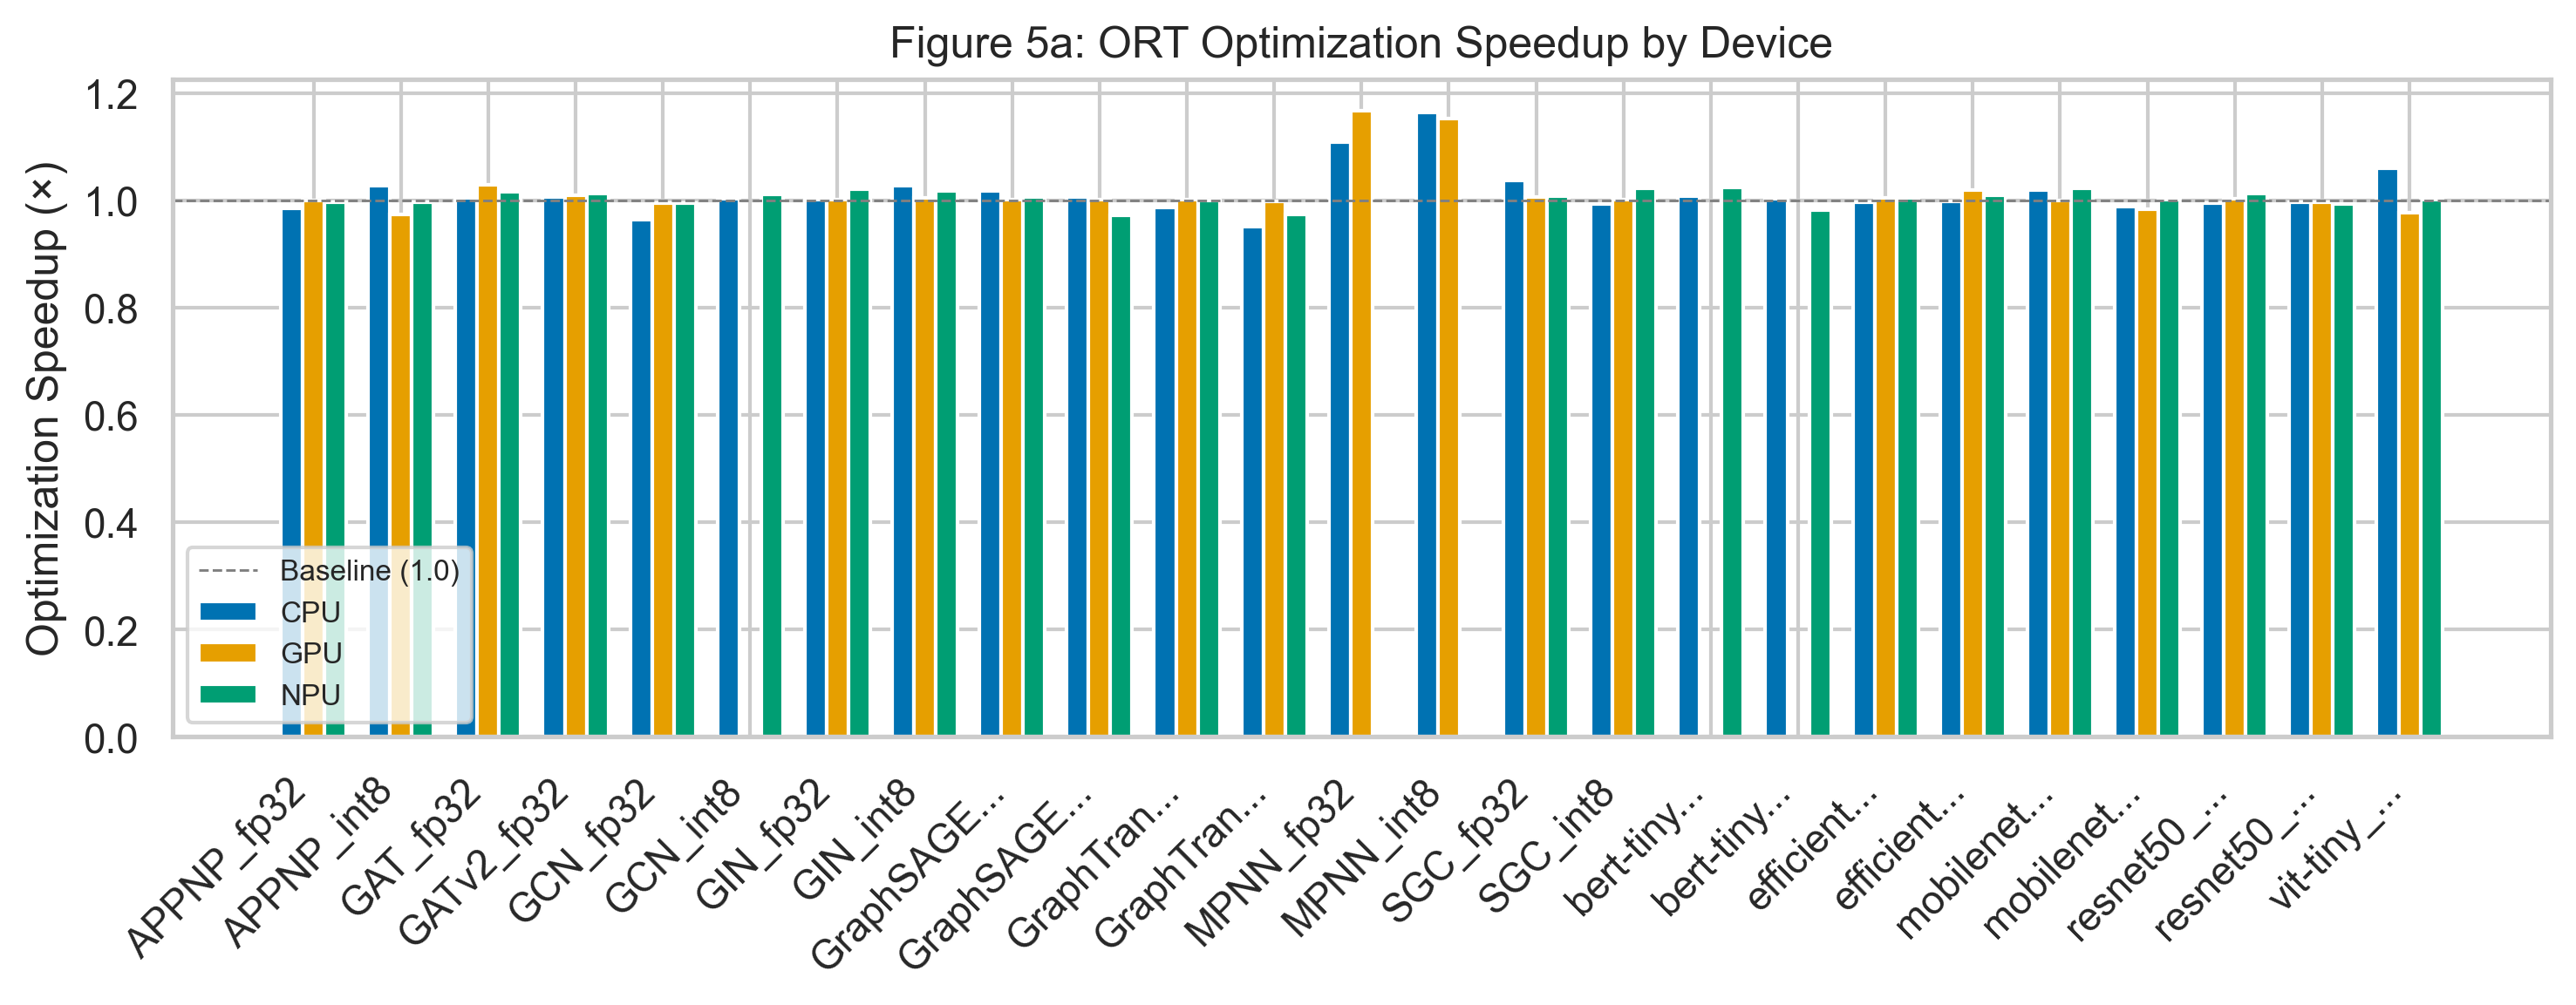

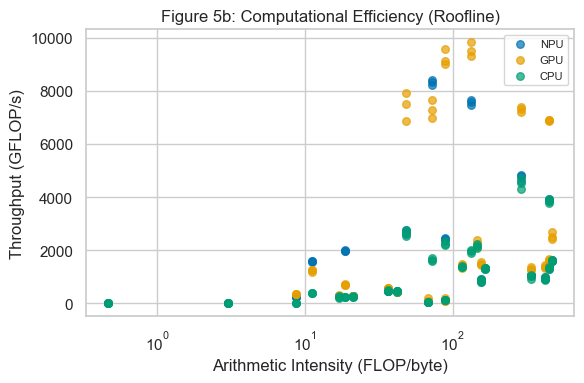

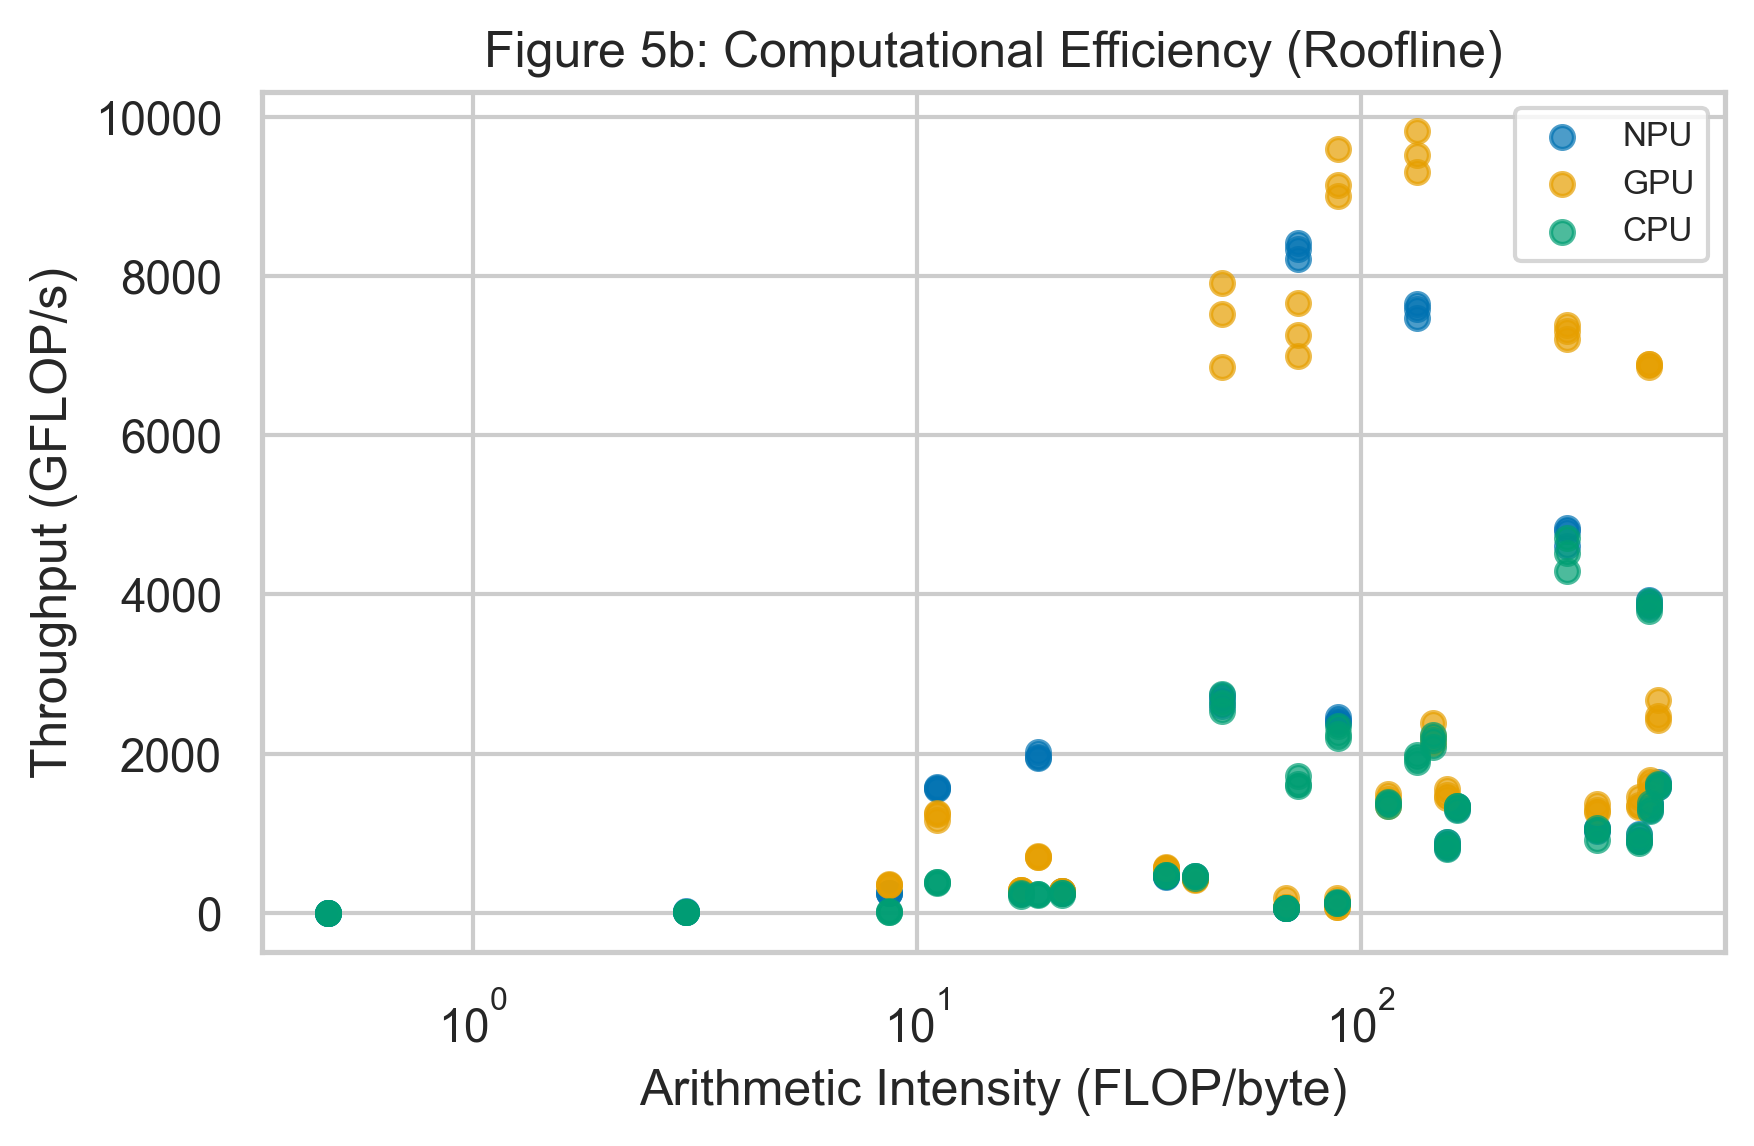

In [26]:
# Stage 4-5: Figure 5 - Optimization speedup & computational efficiency
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()

    dfs = []
    for path in sorted(RESULTS_DIR.glob("*/scalability_matrix.csv")):
        try:
            dfs.append(pd.read_csv(path))
        except Exception:
            continue
    base_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    if base_df.empty:
        print("Data not found: scalability_matrix.csv — skipping Figure 5")
    else:
        # Use available columns: speedup (optimized/baseline ratio) and ai (arithmetic intensity)
        has_speedup = "speedup" in base_df.columns and base_df["speedup"].notna().any()
        has_ai = "ai" in base_df.columns and base_df["ai"].notna().any()
        has_throughput = "throughput_gflops" in base_df.columns
        has_fallback = "o_cpu_fallback_pct" in base_df.columns

        # Panel: Optimization speedup grouped by device
        if has_speedup:
            mean_speedup = base_df.groupby(["model", "device"], as_index=False)["speedup"].mean()
            models = sorted(mean_speedup["model"].unique())
            devices = sorted(mean_speedup["device"].unique())
            x = np.arange(len(models))
            width = 0.25

            fig, ax = plt.subplots(figsize=(10, 4))
            for i, dev in enumerate(devices):
                vals = []
                for m in models:
                    row = mean_speedup[(mean_speedup["model"] == m) & (mean_speedup["device"] == dev)]
                    vals.append(row["speedup"].values[0] if not row.empty else np.nan)
                ax.bar(x + (i - 1) * width, vals, width, label=dev,
                       color=IEEE_COLORS[i % len(IEEE_COLORS)])
            ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.7, label="Baseline (1.0)")
            ax.set_xticks(x)
            ax.set_xticklabels([shorten_label(m, 12) for m in models], rotation=45, ha="right")
            ax.set_ylabel("Optimization Speedup (×)")
            ax.set_title("Figure 5a: ORT Optimization Speedup by Device")
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig5a_opt_speedup")
            display(Image(filename=figures_dir / "fig5a_opt_speedup.png"))

        # Panel: Throughput vs Arithmetic Intensity (roofline-style)
        if has_ai and has_throughput:
            fig, ax = plt.subplots(figsize=(6, 4))
            for dev in ["NPU", "GPU", "CPU"]:
                subset = base_df[(base_df["device"] == dev) & base_df["ai"].notna() & base_df["throughput_gflops"].notna()]
                if subset.empty:
                    continue
                ax.scatter(subset["ai"], subset["throughput_gflops"],
                          label=dev, alpha=0.7, s=30,
                          color=IEEE_COLORS[["NPU", "GPU", "CPU"].index(dev) % len(IEEE_COLORS)])
            ax.set_xlabel("Arithmetic Intensity (FLOP/byte)")
            ax.set_ylabel("Throughput (GFLOP/s)")
            ax.set_title("Figure 5b: Computational Efficiency (Roofline)")
            ax.set_xscale("log")
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig5b_roofline")
            display(Image(filename=figures_dir / "fig5b_roofline.png"))

        # If neither panel is possible, show CPU fallback vs speedup
        if not has_speedup and not (has_ai and has_throughput) and has_fallback:
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.scatter(base_df["o_cpu_fallback_pct"], base_df["speedup"] if has_speedup else 1,
                      alpha=0.6, c=IEEE_COLORS[0])
            ax.set_xlabel("CPU Fallback (%)")
            ax.set_ylabel("Speedup (×)")
            ax.set_title("Figure 5: CPU Fallback vs Speedup")
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig5_fallback_vs_speedup")
            display(Image(filename=figures_dir / "fig5_fallback_vs_speedup.png"))

        if not has_speedup and not has_ai and not has_fallback:
            print("Insufficient data columns for Figure 5 — skipping")
    plt.close('all')

## Stage 4-6: Figure 6 - Scaling characteristics

In [27]:
# Stage 4-6: Figure 6 - Scaling characteristics
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    scaling_dir = RESULTS_DIR / "scaling_sweep"
    scaling_dir.mkdir(parents=True, exist_ok=True)

    # Auto-detect available models if not already set
    if "MODEL_AVAIL" in globals() and MODEL_AVAIL:
        _scale_models = sorted(MODEL_AVAIL.keys())
    elif "AVAILABLE_MODELS" in globals() and AVAILABLE_MODELS:
        _scale_models = AVAILABLE_MODELS
    else:
        # Discover from filesystem
        _scale_models = sorted({p.stem.rsplit("_", 1)[0]
                                for p in MODELS_DIR.glob("*_fp32.onnx")})
    _scale_devices = active_devices if "active_devices" in globals() and active_devices else DEVICES

    existing = list(scaling_dir.glob("*_scaling.csv"))
    if not existing:
        print(f"🔬 Running scaling sweep for {len(_scale_models)} models × {len(_scale_devices)} devices...")
        print("   (This is heavy — set SCALING_SWEEP=0 to skip)")
        if os.environ.get("SCALING_SWEEP", "1") != "0":
            for model in _scale_models:
                for device in _scale_devices:
                    try:
                        cmd = [
                            sys.executable, "analysis/scaling_sweep.py",
                            "--dataset", "ogbn-arxiv",
                            "--device", device,
                            "--model", model,
                            "--dataset-root", "data",
                            "--sizes", "512,1024,2048,4096,8192",
                            "--out-dir", str(scaling_dir),
                            "--iterations", str(ITERATIONS),
                            "--repeats", str(REPEATS),
                            "--warmup", str(WARMUP)
                        ]
                        print(f"   ▶️  {model} @ {device}")
                        subprocess.run(cmd, check=False)
                    except Exception as exc:
                        print(f"   ⚠️  Scaling sweep failed for {model} {device}: {exc}")
            existing = list(scaling_dir.glob("*_scaling.csv"))
        else:
            print("   Scaling sweep disabled by SCALING_SWEEP=0")
    if not existing:
        print("Data not found: scaling_sweep outputs — skipping Figure 6")
    else:
        models = sorted({p.name.split("_")[0] for p in existing})
        devices = sorted({p.name.split("_")[1] for p in existing if "_" in p.name})
        if not models:
            print("No models found in scaling_sweep outputs.")
        else:
            n_models = len(models)
            n_cols = min(2, n_models)
            n_rows = max(1, n_models)
            fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 + 1.2 * n_rows), sharex=False)
            if n_rows == 1:
                axes = np.array([axes])
            for i, model in enumerate(models):
                ax_nodes = axes[i, 0]
                ax_edges = axes[i, 1]
                for j, device in enumerate(devices):
                    path = scaling_dir / f"{model}_{device}_scaling.csv"
                    if not path.exists():
                        continue
                    df = pd.read_csv(path)
                    node_col = "num_nodes" if "num_nodes" in df.columns else ("nodes" if "nodes" in df.columns else None)
                    edge_col = "num_edges" if "num_edges" in df.columns else ("edges" if "edges" in df.columns else None)
                    lat_col = "latency_ms" if "latency_ms" in df.columns else ("mean_ms" if "mean_ms" in df.columns else None)
                    if node_col and lat_col:
                        ax_nodes.plot(df[node_col], df[lat_col], marker="o", label=device,
                                     color=IEEE_COLORS[j % len(IEEE_COLORS)], markersize=3)
                    if edge_col and lat_col:
                        ax_edges.plot(df[edge_col], df[lat_col], marker="s", label=device,
                                     color=IEEE_COLORS[j % len(IEEE_COLORS)], markersize=3)
                ax_nodes.set_title(f"{model} - Nodes", fontsize=9)
                ax_nodes.set_xlabel("Nodes")
                ax_nodes.set_ylabel("Latency (ms)")
                ax_edges.set_title(f"{model} - Edges", fontsize=9)
                ax_edges.set_xlabel("Edges")
                ax_edges.set_ylabel("Latency (ms)")
                ax_nodes.legend(fontsize=7)
            fig.suptitle("Figure 6: Scaling Characteristics", y=1.02)
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig6_scaling")
            display(Image(filename=figures_dir / "fig6_scaling.png"))
    plt.close('all')

🔬 Running scaling sweep for 14 models × 3 devices...
   (This is heavy — set SCALING_SWEEP=0 to skip)
   ▶️  APPNP @ NPU
   ▶️  APPNP @ GPU
   ▶️  APPNP @ CPU
   ▶️  GAT @ NPU
   ▶️  GAT @ GPU
   ▶️  GAT @ CPU
   ▶️  GATv2 @ NPU
   ▶️  GATv2 @ GPU
   ▶️  GATv2 @ CPU
   ▶️  GCN @ NPU
   ▶️  GCN @ GPU
   ▶️  GCN @ CPU
   ▶️  GIN @ NPU
   ▶️  GIN @ GPU
   ▶️  GIN @ CPU
   ▶️  GraphSAGE @ NPU
   ▶️  GraphSAGE @ GPU
   ▶️  GraphSAGE @ CPU
   ▶️  GraphTransformer @ NPU
   ▶️  GraphTransformer @ GPU
   ▶️  GraphTransformer @ CPU
   ▶️  MPNN @ NPU
   ▶️  MPNN @ GPU
   ▶️  MPNN @ CPU
   ▶️  SGC @ NPU
   ▶️  SGC @ GPU
   ▶️  SGC @ CPU
   ▶️  bert-tiny @ NPU
   ▶️  bert-tiny @ GPU
   ▶️  bert-tiny @ CPU
   ▶️  efficientnet-b0 @ NPU
   ▶️  efficientnet-b0 @ GPU
   ▶️  efficientnet-b0 @ CPU
   ▶️  mobilenetv2 @ NPU
   ▶️  mobilenetv2 @ GPU
   ▶️  mobilenetv2 @ CPU
   ▶️  resnet50 @ NPU
   ▶️  resnet50 @ GPU
   ▶️  resnet50 @ CPU
   ▶️  vit-tiny @ NPU
   ▶️  vit-tiny @ GPU
   ▶️  vit-tiny @ CPU
Data

## Stage 4-7: Figure 7 - Density vs NPU latency

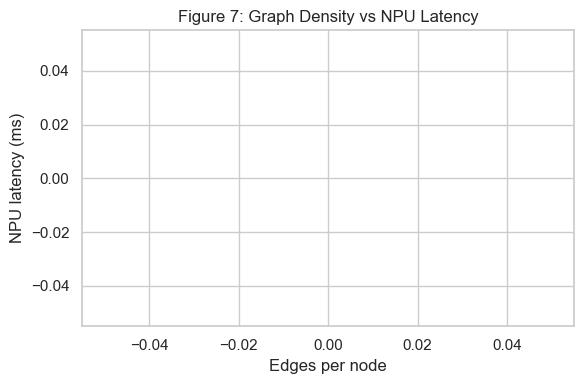

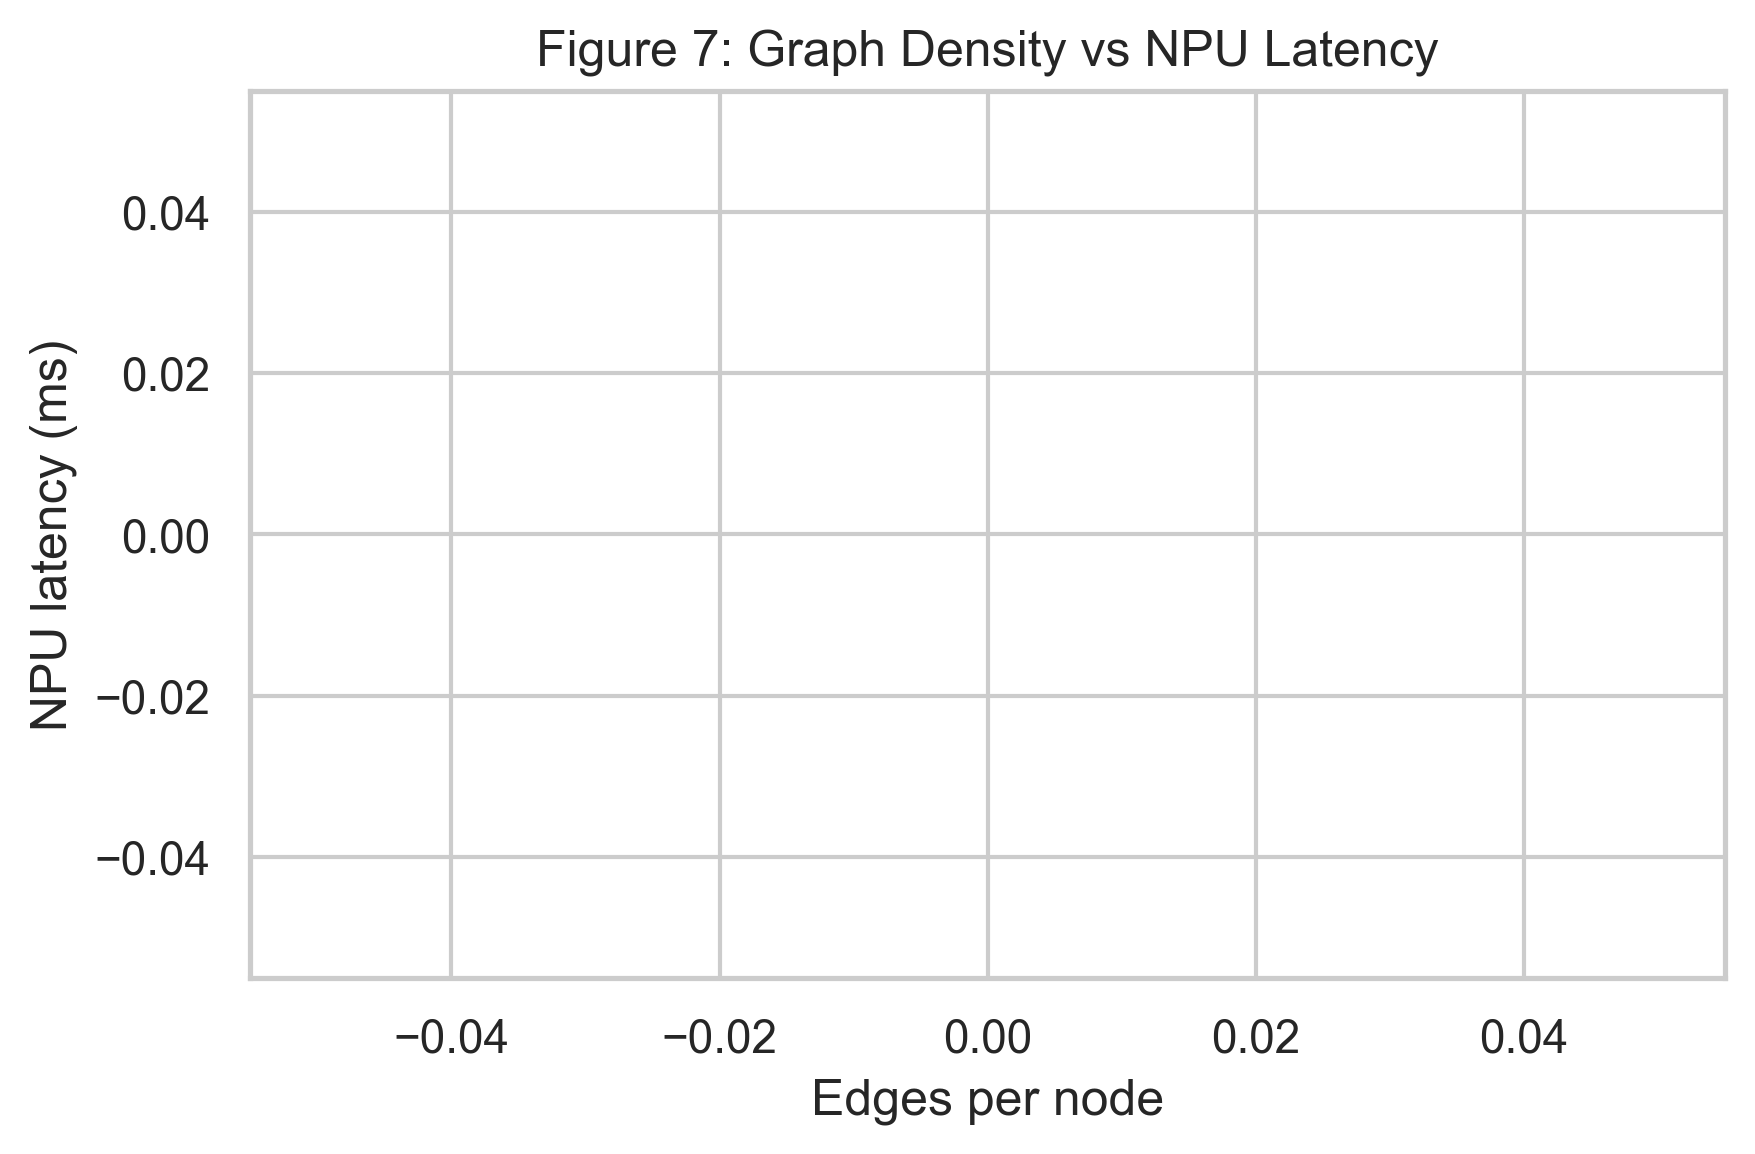

In [28]:
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()
    if "master_results_df" not in globals() or master_results_df.empty:
        master_path = figures_dir / "master_results.csv"
        if master_path.exists():
            master_results_df = pd.read_csv(master_path)
    if "dataset_stats" not in globals() or dataset_stats is None or dataset_stats.empty:
        dataset_stats_path = figures_dir / "dataset_stats.csv"
        if dataset_stats_path.exists():
            dataset_stats = pd.read_csv(dataset_stats_path)
    if "master_results_df" not in globals() or master_results_df.empty or "dataset_stats" not in globals() or dataset_stats.empty:
        print("Data not found: master_results_df or dataset_stats")
    else:
        npu_df = master_results_df[(master_results_df["device"] == "NPU") & (master_results_df["precision"] == "fp32")]
        npu_df = npu_df.groupby(["model", "dataset"], as_index=False)["mean_ms"].mean()
        merged = npu_df.merge(dataset_stats[["dataset", "edges_per_node"]], on="dataset", how="inner")
        if merged.empty:
            print("No matching density/latency data found.")
        else:
            fig, ax = plt.subplots(figsize=(6, 4))
            datasets = merged["dataset"].unique()
            model_markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
            model_marker_map = {m: model_markers[i % len(model_markers)] for i, m in enumerate(sorted(merged["model"].unique()))}
            for i, dataset in enumerate(datasets):
                subset = merged[merged["dataset"] == dataset]
                for _, row in subset.iterrows():
                    ax.scatter(row["edges_per_node"], row["mean_ms"], color=IEEE_COLORS[i % len(IEEE_COLORS)], marker=model_marker_map[row["model"]], alpha=0.8)
            if merged["edges_per_node"].notna().any():
                sns.regplot(x="edges_per_node", y="mean_ms", data=merged, scatter=False, ax=ax, color="black")
                r, p = stats.pearsonr(merged["edges_per_node"], merged["mean_ms"])
                ax.text(0.02, 0.98, f"r={r:.2f}, p={p:.3f}", transform=ax.transAxes, va="top")
            ax.set_xlabel("Edges per node")
            ax.set_ylabel("NPU latency (ms)")
            ax.set_title("Figure 7: Graph Density vs NPU Latency")
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig7_density_vs_latency")
            display(Image(filename=figures_dir / "fig7_density_vs_latency.png"))
    plt.close('all')

## Stage 4-8: Figure 8 - Energy consumption

⚠️  SoCWatch power data unavailable (admin required).
   → Using NPU speedup vs CPU/GPU as energy-efficiency proxy.


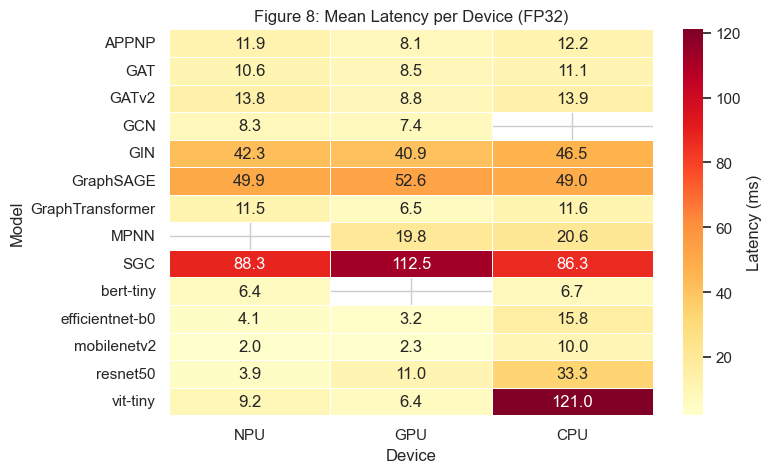

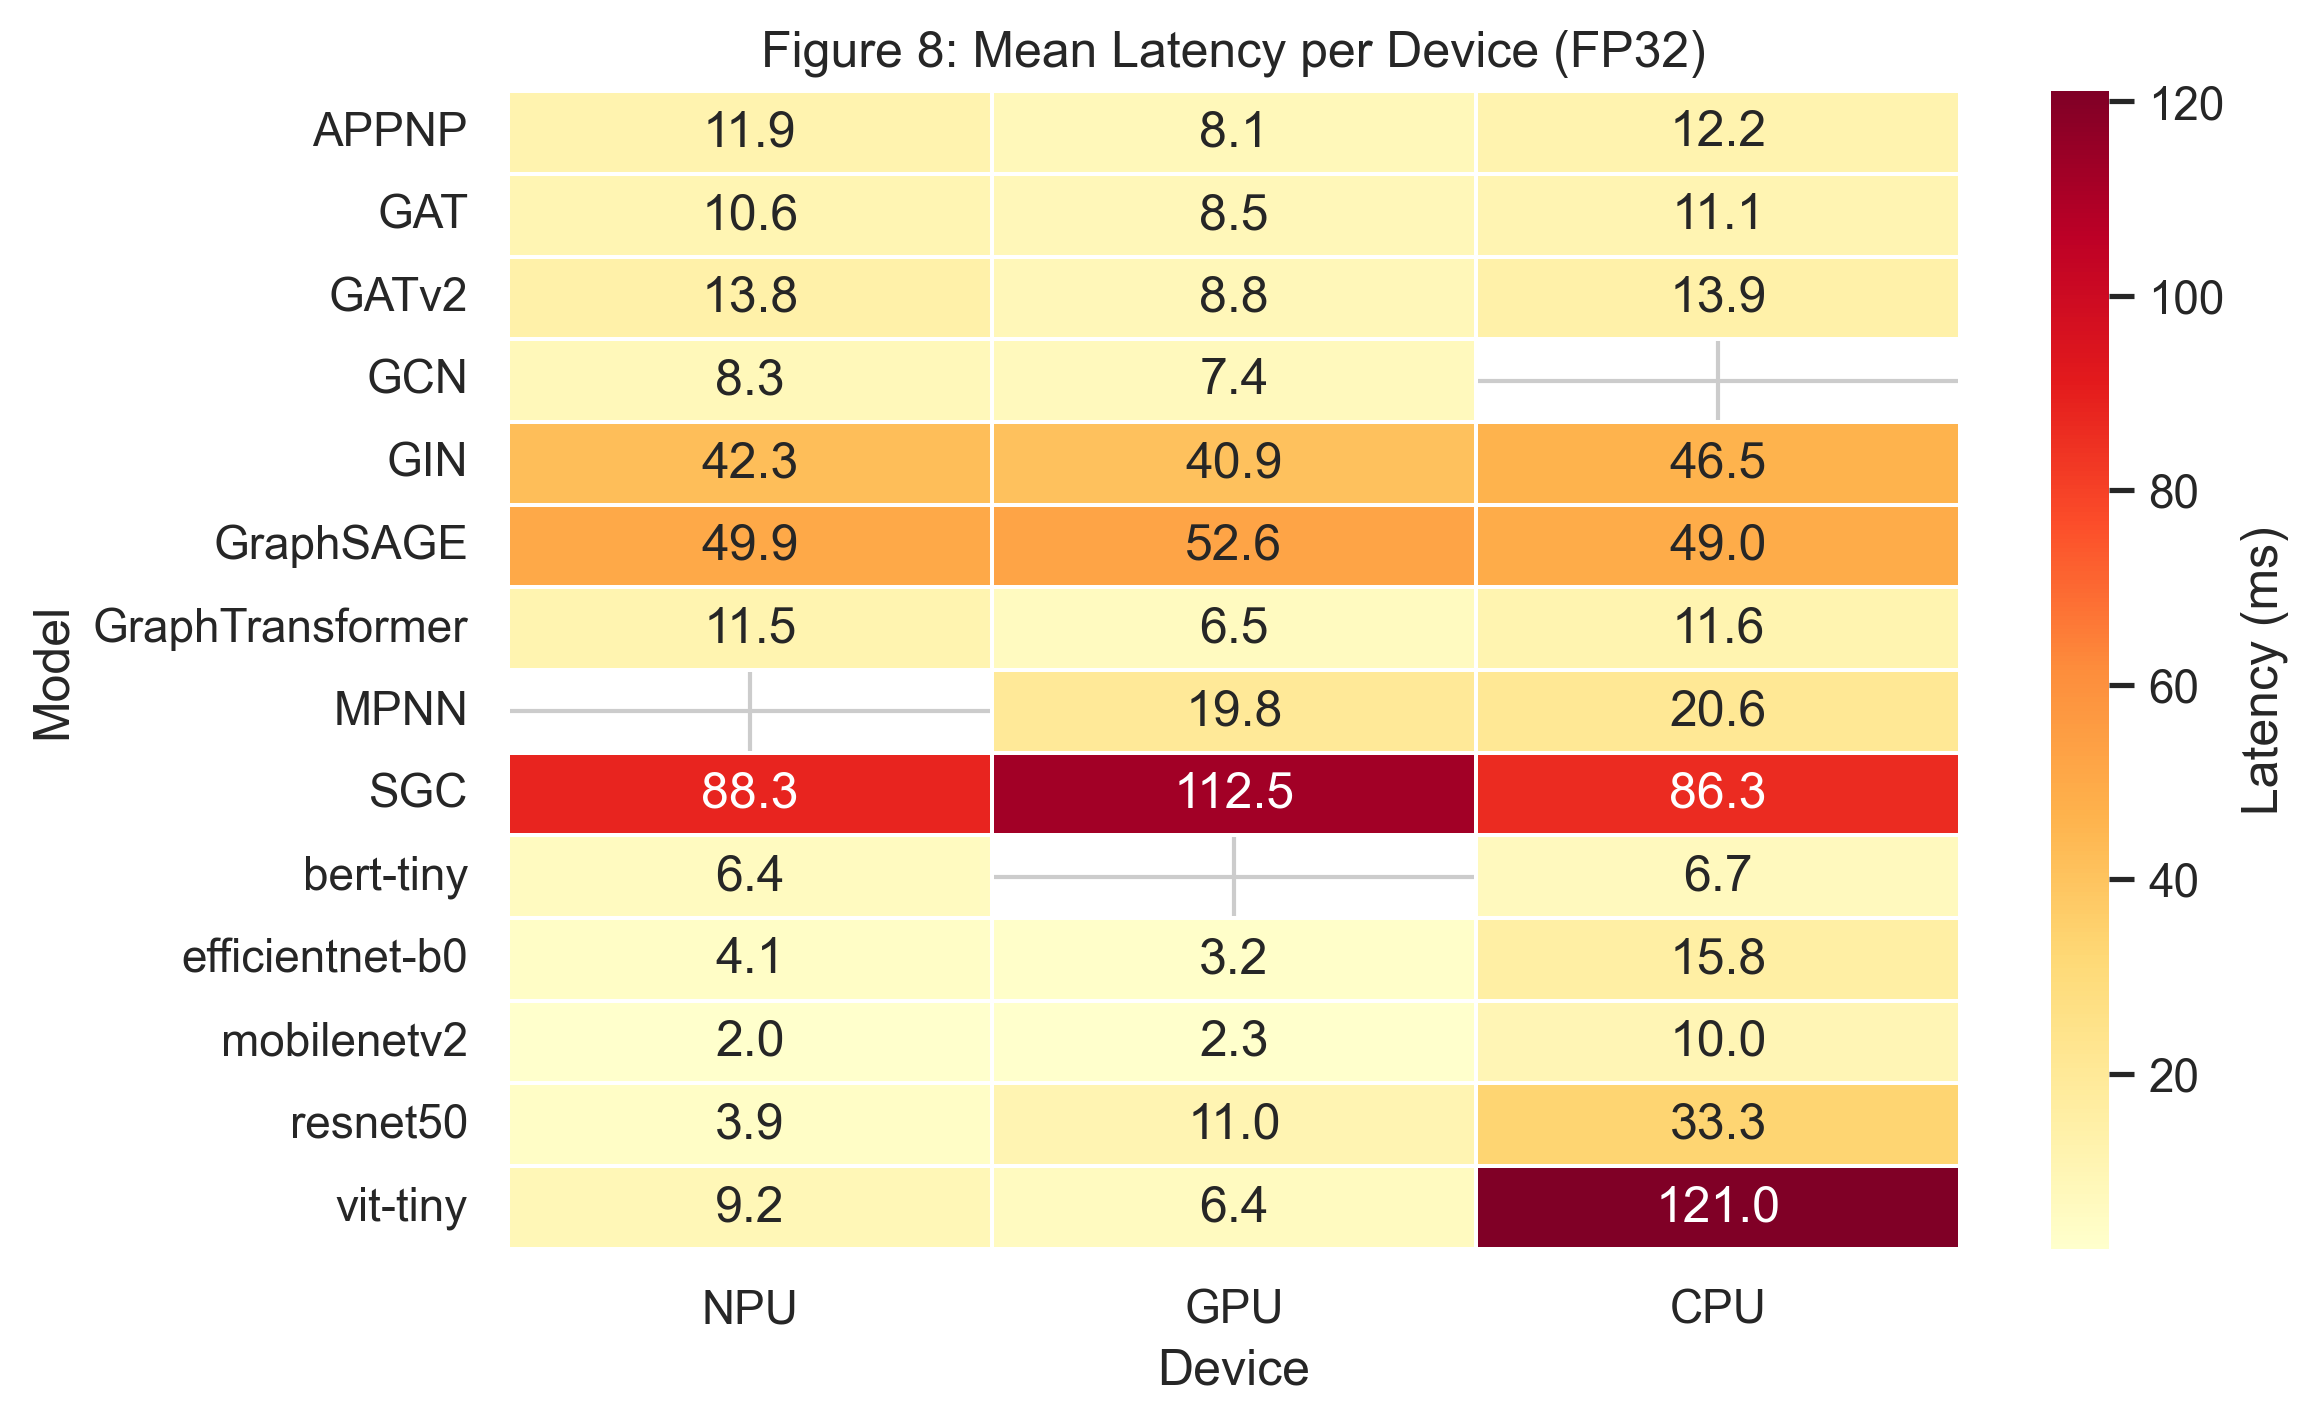

In [29]:
# Stage 4-8: Figure 8 - Energy efficiency (SoCWatch) or latency-proxy
if "pd" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    apply_ieee_style()

    # --- Try loading SoCWatch energy data ---
    rows = []
    component_rows = []
    for path in sorted(RESULTS_DIR.glob("*/energy.json")):
        model = path.parent.name
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if payload.get("error"):
            for dev in DEVICES:
                rows.append({"model": model, "device": dev, "total_mJ": np.nan})
            continue
        for device in DEVICES:
            key = f"{device}_fp32"
            entry = payload.get(key)
            if isinstance(entry, dict):
                rows.append({"model": model, "device": device, "total_mJ": entry.get("total_mJ")})
            else:
                rows.append({"model": model, "device": device, "total_mJ": np.nan})
        npu_entry = payload.get("NPU_fp32")
        if isinstance(npu_entry, dict):
            component_rows.append({
                "model": model,
                "ia_mW": npu_entry.get("ia_mW"),
                "gt_mW": npu_entry.get("gt_mW"),
                "dram_mW": npu_entry.get("dram_mW")
            })

    energy_df = pd.DataFrame(rows)
    comp_df = pd.DataFrame(component_rows)

    has_energy = (not energy_df.empty and
                  energy_df["total_mJ"].notna().any() and
                  energy_df["total_mJ"].sum() > 0)

    # --- Alternative: NPU speedup heatmap (if SoCWatch unavailable) ---
    if not has_energy:
        print("⚠️  SoCWatch power data unavailable (admin required).")
        print("   → Using NPU speedup vs CPU/GPU as energy-efficiency proxy.")

        # Load master results for NPU speedup comparison
        if "master_results_df" not in globals() or master_results_df.empty:
            _mp = figures_dir / "master_results.csv"
            if _mp.exists():
                master_results_df = pd.read_csv(_mp)

        if "master_results_df" in globals() and not master_results_df.empty:
            _fp = master_results_df[master_results_df["precision"] == "fp32"].copy()
            # Clean model names (remove _fp32 suffix)
            _fp["model"] = _fp["model"].str.replace("_fp32", "", regex=False)
            _pivot = _fp.pivot_table(index="model", columns="device", values="mean_ms", aggfunc="mean")
            _pivot = _pivot[["NPU", "GPU", "CPU"]] if all(c in _pivot.columns for c in ["NPU", "GPU", "CPU"]) else _pivot

            fig, ax = plt.subplots(figsize=(8, max(4, len(_pivot) * 0.35)))
            sns.heatmap(_pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".1f",
                       linewidths=0.5, cbar_kws={"label": "Latency (ms)"})
            ax.set_title("Figure 8: Mean Latency per Device (FP32)")
            ax.set_ylabel("Model")
            ax.set_xlabel("Device")
            plt.tight_layout()
            plt.show()
            save_figure_dual_format(fig, figures_dir / "fig8_latency_heatmap")
            display(Image(filename=figures_dir / "fig8_latency_heatmap.png"))
        else:
            print("   No master_results data available — skipping Figure 8")

    else:
        # --- SoCWatch energy data IS available — show real energy plots ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        ax_left, ax_right = axes
        models = sorted(energy_df["model"].unique())
        x = np.arange(len(models))
        width = 0.25

        for i, device in enumerate(["NPU", "GPU", "CPU"]):
            vals = []
            for model in models:
                row = energy_df[(energy_df["model"] == model) & (energy_df["device"] == device)]
                val = row["total_mJ"].values[0] if not row.empty else np.nan
                vals.append(val if val is not None else np.nan)
            ax_left.bar(x + (i - 1) * width, vals, width, label=device,
                       color=IEEE_COLORS[i % len(IEEE_COLORS)])
        ax_left.set_title("Figure 8a: Energy per Inference (FP32)")
        ax_left.set_ylabel("Total energy (mJ)")
        ax_left.set_xticks(x)
        ax_left.set_xticklabels([shorten_label(m, 12) for m in models], rotation=45, ha="right")
        ax_left.legend()

        if comp_df.empty:
            ax_right.text(0.5, 0.5, "Power components N/A", ha="center", va="center", transform=ax_right.transAxes)
            ax_right.axis("off")
        else:
            comp_df = comp_df.set_index("model").reindex(models).fillna(0)
            ia = comp_df["ia_mW"].values
            gt = comp_df["gt_mW"].values
            dram = comp_df["dram_mW"].values
            ax_right.bar(x, ia, label="IA", color=IEEE_COLORS[0])
            ax_right.bar(x, gt, bottom=ia, label="GT", color=IEEE_COLORS[1])
            ax_right.bar(x, dram, bottom=ia + gt, label="DRAM", color=IEEE_COLORS[2])
            ax_right.set_title("Figure 8b: NPU Power Components (mW)")
            ax_right.set_xticks(x)
            ax_right.set_xticklabels([shorten_label(m, 12) for m in models], rotation=45, ha="right")
            ax_right.legend(fontsize=8)

        fig.suptitle("Figure 8: Energy Consumption (SoCWatch)", y=1.02)
        plt.tight_layout()
        plt.show()
        save_figure_dual_format(fig, figures_dir / "fig8_energy_comparison")
        display(Image(filename=figures_dir / "fig8_energy_comparison.png"))

    plt.close('all')

## Output inventory

In [30]:
if "Path" not in globals():
    print("Stage 0 not executed. Please run the global setup cell.")
else:
    figures_dir = FIGURES_DIR if "FIGURES_DIR" in globals() else Path("results/figures")
    if figures_dir.exists():
        files = sorted([p for p in figures_dir.iterdir() if p.suffix.lower() in {".png", ".svg", ".csv"}])
        print("Figures directory outputs:")
        for p in files:
            size_kb = p.stat().st_size / 1024
            print(f"- {p.name}: {size_kb:.1f} KB")
    else:
        print("results/figures not found.")
    print("")
    model_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name not in {"figures", "density_sweep", "scaling_sweep"}]
    for model_dir in sorted(model_dirs):
        files = list(model_dir.rglob("*"))
        files = [p for p in files if p.is_file()]
        total_size = sum(p.stat().st_size for p in files)
        print(f"{model_dir.name}: {len(files)} files, {total_size / 1024:.1f} KB")
    if "RUN_START_TIME" in globals():
        elapsed_s = time.time() - RUN_START_TIME
        print(f"Elapsed time: {elapsed_s / 60:.1f} min")

Figures directory outputs:
- comparison_table.csv: 2.0 KB
- dataset_stats.csv: 0.3 KB
- fig1_latency_comparison.png: 209.6 KB
- fig1_latency_comparison.svg: 64.7 KB
- fig2_int8_speedup_heatmap.png: 145.8 KB
- fig2_int8_speedup_heatmap.svg: 59.6 KB
- fig3_operator_breakdown.png: 182.4 KB
- fig3_operator_breakdown.svg: 72.6 KB
- fig4_cpu_fallback_heatmap.png: 258.8 KB
- fig4_cpu_fallback_heatmap.svg: 67.9 KB
- fig5a_opt_speedup.png: 222.2 KB
- fig5a_opt_speedup.svg: 83.9 KB
- fig5b_roofline.png: 147.9 KB
- fig5b_roofline.svg: 68.4 KB
- fig7_density_vs_latency.png: 61.2 KB
- fig7_density_vs_latency.svg: 36.8 KB
- fig8_latency_heatmap.png: 210.3 KB
- fig8_latency_heatmap.svg: 71.0 KB
- master_results.csv: 10.4 KB
- operator_mix.csv: 1.4 KB
- summary_stats.csv: 3.7 KB
- unified_summary.csv: 6.0 KB

APPNP: 43 files, 2495.8 KB
bert-tiny: 45 files, 10823.5 KB
efficientnet-b0: 37 files, 2478.8 KB
GAT: 24 files, 1374.4 KB
GATv2: 24 files, 1387.4 KB
GCN: 45 files, 2475.3 KB
GIN: 43 files, 2484.5 